# Cross-chain master vault CCTP backtest, capped waterfall allocator

Based on `scratchpad/xchain2/07-backtest-rolling-top15-full-universe.ipynb`.

This variant keeps the same executable vault universe as NB07: the monthly top-20 native-USDC union generated by `scripts/larger-filter-top-vaults.py`, with 200 vaults after excluding two script-selected Ethereum vaults that cannot run in the current backtest.

The strategy change is allocator-only: use the Hyperliquid capped-waterfall method from the vault-of-vaults notebook lineage. Instead of targeting an 85% invested book with up to 12 names, this variant targets 90% allocation, allows up to 20 selected positions, keeps the 12% per-vault concentration cap, and lets `AlphaModel.normalise_weights(..., waterfall=True)` greedily fill ranked 3-month CAGR candidates subject to TVL, concentration, redemption, and settlement constraints.

Universe construction prompt inherited from NB07:

```text
- Update the filter script to do the real top 20 * chain * month rows inclusion criteria
- For each month, apply filters separately
- The final vault set should be union of any vault ever included
```

Allocator prompt:

```text
Do new notebook with the same universe, but use capped waterfall method.
```

Script command used for the universe:

```shell
poetry run python scripts/larger-filter-top-vaults.py \
  --rolling-top-detection \
  --chain-ids 1,8453,42161,999,143 \
  --denominations USDC \
  --min-tvl 100000 \
  --min-age 0 \
  --rolling-top-per-chain 20 \
  --rolling-window-days 90 \
  --always-include ostium,gains,plutus,ember,d2 \
  --json
```

Note: this cross-chain CCTP variant uses a 90% allocation target instead of the Hyperliquid single-chain 98% target, because the first 98% run hit a small primary-chain USDC funding shortfall during bridge planning on 2026-01-05.

The explicit cash buffer is subtracted from the waterfall deployable target before sizing, to avoid CCTP bridge planning failures where primary-chain buys and satellite bridge shortfalls consume the primary USDC reserve to the dollar.


## Notebook setup

Set up the Trading Strategy client, chart output, and imports used throughout the notebook.


In [1]:
import datetime
import logging
import os

import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display
from dotenv import load_dotenv
from eth_defi.token import USDC_NATIVE_TOKEN
from plotly.graph_objects import Figure
from tradingstrategy.chain import ChainId
from tradingstrategy.client import Client
from tradingstrategy.timebucket import TimeBucket
from tradingstrategy.utils.token_filter import filter_for_selected_pairs

from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.curator import is_quarantined
from tradeexecutor.ethereum.vault.checks import check_stale_vault_data
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.chart.definition import ChartInput, ChartKind, ChartRegistry
from tradeexecutor.strategy.chart.standard.alpha_model import (
    alpha_model_diagnostics,
    missed_vault_deposit_redemption_events,
    missed_vault_deposit_redemption_timeline,
)
from tradeexecutor.strategy.chart.standard.equity_curve import (
    equity_curve as equity_curve_chart,
    equity_curve_with_drawdown,
)
from tradeexecutor.strategy.chart.standard.interest import vault_statistics
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.position import positions_at_end
from tradeexecutor.strategy.chart.standard.profit_breakdown import trading_pair_breakdown
from tradeexecutor.strategy.chart.standard.thinking import last_messages
from tradeexecutor.strategy.chart.standard.trading_metrics import trading_metrics
from tradeexecutor.strategy.chart.standard.trading_universe import (
    available_trading_pairs,
    inclusion_criteria_check,
)
from tradeexecutor.strategy.chart.standard.vault import all_vault_positions
from tradeexecutor.strategy.chart.standard.weight import (
    equity_curve_by_asset,
    equity_curve_by_chain,
    weight_allocation_statistics,
)
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.execution_context import ExecutionContext, ExecutionMode, notebook_execution_context
from tradeexecutor.strategy.pandas_trader.indicator import (
    IndicatorDependencyResolver,
    IndicatorSource,
)
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.reserve_currency import ReserveCurrency
from tradeexecutor.strategy.tag import StrategyTag
from tradeexecutor.strategy.trading_strategy_universe import (
    TradingStrategyUniverse,
    load_partial_data,
    load_vault_universe_with_metadata,
)
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.utils.notebook import OutputMode, display_head_and_tail, setup_charting_and_output
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

load_dotenv(override=True)
setup_charting_and_output(OutputMode.static, image_format="png", width=1500, height=900)

api_key = os.environ.get("TRADING_STRATEGY_API_KEY")
client = Client.create_jupyter_client(api_key=api_key)
logger = logging.getLogger("strategy")

trading_strategy_engine_version = "0.5"

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /home/mikko/.tradingstrategy


## Universe definition

Monthly rolling top-20 native-USDC vault universe on Ethereum, Base, Arbitrum, HyperEVM, and Monad, with synthetic CCTP bridge pairs for non-primary chains. For each chain and month, filters are applied to that historical monthly snapshot, the top 20 vaults by 90-day CAGR are selected, and the final universe is the union of all selected vaults. The script output contains 202 vaults; this executable notebook uses 200 after excluding two script-selected Ethereum vaults that cannot run in the current backtest.

In [2]:
LENDING_RESERVES = None

SUPPORTING_PAIRS = [
    (ChainId.ethereum, "uniswap-v3", "WETH", "USDC", 0.0005),
    (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.003),
    (ChainId.arbitrum, "uniswap-v3", "WETH", "USDC", 0.0005),
    (ChainId.base, "uniswap-v3", "WETH", "USDC", 0.0005),
]

SOURCE_VAULTS = [
    # Monthly rolling top-20 native-USDC vault universe generated with:
    # poetry run python scripts/larger-filter-top-vaults.py --rolling-top-detection --chain-ids 1,8453,42161,999,143 --denominations USDC --min-tvl 100000 --min-age 0 --rolling-top-per-chain 20 --rolling-window-days 90 --always-include ostium,gains,plutus,ember,d2 --json
    # Semantics: for each chain and month, calculate 90-day CAGR from historical share price, apply filters on that monthly snapshot, select the top 20, then union all selected vaults.
    # Filters: native USDC, not blacklisted/dangerous, lower than Severe risk unless always included, known protocol/risk unless always included, no Morpho flags, historical monthly TVL >= $100k, age >= 0.
    # Always include protocols: Ostium, Gains, Plutus, Ember, D2.
    # Script output: 202 vaults.
    # Notebook output: 200 vaults after excluding 2 script-selected vaults that cannot run in the current backtest.
    # Excluded: Ethereum USDC (0xc155444481854c60e7a29f4150373f479988f32d) - infrastructure-incompatible: vault share asset collides with Ethereum USDC reserve accounting.
    # Excluded: Ethereum Api3 dCOMP USDC (0x36cfe1568461e499391ef0a555300f1ae2da2439) - missing from the current vault metadata loaded by the backtest.
    # Ordered satellite chains first so tied CAGR scores favour capital deployment away from Ethereum.
    # Harvest: USDC Vault (0x9061) (harvest-finance, current TVL=$88,174, first monthly top-20=2024-04-30, original top APY=39.61%, original top TVL=$177,929, current 3m APY=0.00%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0x90613e167d42ca420942082157b42af6fc6a8087"),
    # Gauntlet USDC Core (morpho, current TVL=$1,972,743, first monthly top-20=2024-09-30, original top APY=2.07%, original top TVL=$4,068,102, current 3m APY=3.90%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xc0c5689e6f4d256e861f65465b691aeecc0deb12"),
    # Gauntlet USDC Prime (morpho, current TVL=$433,518,396, first monthly top-20=2024-09-30, original top APY=2.23%, original top TVL=$1,032,170, current 3m APY=4.31%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xee8f4ec5672f09119b96ab6fb59c27e1b7e44b61"),
    # Moonwell Flagship USDC (morpho, current TVL=$9,704,856, first monthly top-20=2024-09-30, original top APY=1.45%, original top TVL=$32,568,992, current 3m APY=3.67%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xc1256ae5ff1cf2719d4937adb3bbccab2e00a2ca"),
    # Steakhouse USDC (morpho, current TVL=$224,884,242, first monthly top-20=2024-09-30, original top APY=2.28%, original top TVL=$983,762, current 3m APY=3.21%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xbeef010f9cb27031ad51e3333f9af9c6b1228183"),
    # Fluid USD Coin (fluid, current TVL=$8,634,033, first monthly top-20=2024-11-30, original top APY=9.83%, original top TVL=$12,917,075, current 3m APY=4.95%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xf42f5795d9ac7e9d757db633d693cd548cfd9169"),
    # gTrade (Gains Network USDC) (gains-network, current TVL=$2,390,865, first monthly top-20=2024-12-31, original top APY=15.40%, original top TVL=$1,925,598, current 3m APY=3.11%, risk=Unknown, reason=always_include:gains)
    (ChainId.base, "0xad20523a7dc37babc1cc74897e4977232b3d02e5"),
    # Harvest: USDC Vault (0xcEa7) (harvest-finance, current TVL=$22,955, first monthly top-20=2025-01-31, original top APY=15.79%, original top TVL=$111,024, current 3m APY=5.52%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xcea7de485cf3b69cf3d5f7dfadf9e1df31303988"),
    # IPOR USDC Lending Optimizer Base (ipor-fusion, current TVL=$232,600, first monthly top-20=2025-03-30, original top APY=13.79%, original top TVL=$1,428,433, current 3m APY=3.08%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0x45aa96f0b3188d47a1dafdbefce1db6b37f58216"),
    # AlphaGrowth Base (euler, current TVL=$325,673, first monthly top-20=2025-04-30, original top APY=5.11%, original top TVL=$7,899,905, current 3m APY=3.12%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x0a1a3b5f2041f33522c4efc754a7d096f880ee16"),
    # Apostro Resolv (euler, current TVL=$16,508, first monthly top-20=2025-04-30, original top APY=8.89%, original top TVL=$471,111, current 3m APY=86.47%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xc063c3b3625df5f362f60f35b0bcd98e0fa650fb"),
    # Spark USDC Vault (morpho, current TVL=$7,908,100, first monthly top-20=2025-04-30, original top APY=5.48%, original top TVL=$114,470,304, current 3m APY=3.89%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x7bfa7c4f149e7415b73bdedfe609237e29cbf34a"),
    # Aerodrome USDC (40acres, current TVL=$7,419,195, first monthly top-20=2025-05-31, original top APY=30.34%, original top TVL=$3,178,720, current 3m APY=9.75%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xb99b6df96d4d5448cc0a5b3e0ef7896df9507cf5"),
    # Summer.fi USDC (summer-fi, current TVL=$956,554, first monthly top-20=2025-05-31, original top APY=5.45%, original top TVL=$6,482,356, current 3m APY=3.33%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0x98c49e13bf99d7cad8069faa2a370933ec9ecf17"),
    # Harvest: USDC Vault (0xD9e3) (harvest-finance, current TVL=$93,398, first monthly top-20=2025-06-29, original top APY=24.00%, original top TVL=$715,299, current 3m APY=14.06%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xd9e38d724cc5ee983bc0fd0ce35c3eb20417b673"),
    # Clearstar USDC Reactor (morpho, current TVL=$1,587,076, first monthly top-20=2025-06-30, original top APY=4.94%, original top TVL=$2,724,633, current 3m APY=4.66%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x1d3b1cd0a0f242d598834b3f2d126dc6bd774657"),
    # Moonwell USDC Lender WETH Borrower (yearn, current TVL=$2,015, first monthly top-20=2025-07-05, original top APY=20.22%, original top TVL=$106,972, current 3m APY=0.00%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xfdb431e661372fa1146efb70bf120ecded944a78"),
    # Autopilot USDC Base (ipor-fusion, current TVL=$894,080, first monthly top-20=2025-07-31, original top APY=8.91%, original top TVL=$3,413,006, current 3m APY=4.76%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0x0d877dc7c8fa3ad980dfdb18b48ec9f8768359c4"),
    # Harvest: USDC Vault (0x00f2) (harvest-finance, current TVL=$9,267, first monthly top-20=2025-07-31, original top APY=9.90%, original top TVL=$810,731, current 3m APY=4.59%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0x00f281832f74d3eb391c219148ee3b7c8bb46319"),
    # Tokemak baseUSD (auto-finance, current TVL=$7,081,451, first monthly top-20=2025-08-30, original top APY=9.03%, original top TVL=$27,589,121, current 3m APY=5.26%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0x9c6864105aec23388c89600046213a44c384c831"),
    # Harvest: USDC Vault (0xC777) (harvest-finance, current TVL=$1,856,295, first monthly top-20=2025-08-31, original top APY=12.57%, original top TVL=$2,555,027, current 3m APY=9.46%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xc777031d50f632083be7080e51e390709062263e"),
    # Yearn OG USDC (morpho, current TVL=$1,966,643, first monthly top-20=2025-08-31, original top APY=6.91%, original top TVL=$170,235, current 3m APY=4.79%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xef417a2512c5a41f69ae4e021648b69a7cde5d03"),
    # Gauntlet USDC Frontier (morpho, current TVL=$257,572, first monthly top-20=2025-09-30, original top APY=6.76%, original top TVL=$1,025,635, current 3m APY=5.22%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x236919f11ff9ea9550a4287696c2fc9e18e6e890"),
    # Harvest: USDC Vault (0xed5A) (harvest-finance, current TVL=$15,706, first monthly top-20=2025-10-29, original top APY=13.34%, original top TVL=$116,772, current 3m APY=6.23%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xed5a6691a3663045c6d9f12f334fbc796ee12f45"),
    # AlphaGrowth YO yoUSD Market (euler, current TVL=$23,906, first monthly top-20=2025-10-31, original top APY=7.18%, original top TVL=$1,177,918, current 3m APY=4.81%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x085178078796da17b191f9081b5e2fccc79a7ee7"),
    # High Yield Clearstar USDC (morpho, current TVL=$752,171, first monthly top-20=2025-10-31, original top APY=7.75%, original top TVL=$9,524,166, current 3m APY=5.01%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xe74c499fa461af1844fca84204490877787ced56"),
    # Steakhouse Prime USDC (morpho, current TVL=$228,067,822, first monthly top-20=2025-11-30, original top APY=7.02%, original top TVL=$70,008,745, current 3m APY=4.28%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xbeefe94c8ad530842bfe7d8b397938ffc1cb83b2"),
    # DeFi Janus Henderson Anemoy AAA CLO Fund Token (centrifuge, current TVL=$2,221,038, first monthly top-20=2025-12-31, original top APY=7.58%, original top TVL=$970,547, current 3m APY=4.61%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x2d38c58cc7d4ddd6b4daf7b3539902a7667f4519"),
    # DeTrade Core USDC (lagoon-finance, current TVL=$629,972, first monthly top-20=2025-12-31, original top APY=38.91%, original top TVL=$794,495, current 3m APY=5.71%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0x8092ca384d44260ea4feaf7457b629b8dc6f88f0"),
    # True Yield Dollar (yearn, current TVL=$662,972, first monthly top-20=2025-12-31, original top APY=6.83%, original top TVL=$2,416,132, current 3m APY=2.85%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xb13cf163d916917d9cd6e836905ca5f12a1def4b"),
    # USDC Fluid Lender (fluid, current TVL=$18,223, first monthly top-20=2025-12-31, original top APY=26.82%, original top TVL=$2,855,631, current 3m APY=15.35%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0x70fffbacb53ef74903ac074aae769414a70970d1"),
    # yoUSD Looopeer (ipor-fusion, current TVL=$815,593, first monthly top-20=2025-12-31, original top APY=12.82%, original top TVL=$2,077,887, current 3m APY=-21.55%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0x1166250d1d6b5a1dbb73526257f6bb2bbe235295"),
    # Autopilot USDC Morpho (Base) (ipor-fusion, current TVL=$75,602, first monthly top-20=2026-01-27, original top APY=7.61%, original top TVL=$102,283, current 3m APY=4.72%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xd6701905c59ee618dc36dc747506bce0a4ac760a"),
    # Steakhouse High Yield USDC (morpho, current TVL=$57,795, first monthly top-20=2026-01-31, original top APY=8.32%, original top TVL=$273,263, current 3m APY=3.41%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xcbeef01994e24a60f7dcb8de98e75ad8bd4ad60d"),
    # Chimi USDC Vault (yearn, current TVL=$240,880, first monthly top-20=2026-02-26, original top APY=9.60%, original top TVL=$108,892, current 3m APY=8.79%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xcb2f26898c0893c0bdd5cf76417cf9b2258af0ed"),
    # 722Capital-USDC (lagoon-finance, current TVL=$823,561, first monthly top-20=2026-02-28, original top APY=10.35%, original top TVL=$1,326,305, current 3m APY=-8.22%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xb09f761cb13baca8ec087ac476647361b6314f98"),
    # AlphaGrowth Base RWA (euler, current TVL=$585,466, first monthly top-20=2026-02-28, original top APY=5.37%, original top TVL=$526,148, current 3m APY=8.02%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x4c1aeda9b43efcf1da1d1755b18802aabe90f61e"),
    # GUSDC (lagoon-finance, current TVL=$266,216, first monthly top-20=2026-02-28, original top APY=11.71%, original top TVL=$237,474, current 3m APY=-0.93%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xd5c22fa3f7ee979ed7c28e36669b29797ab277e4"),
    # Gauntlet USDC Frontier (morpho, current TVL=$2,430,600, first monthly top-20=2026-02-28, original top APY=6.90%, original top TVL=$4,700,581, current 3m APY=5.31%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x1deefabee758aabdc29a542b24ca3b75afd56765"),
    # Gauntlet USDC Prime (morpho, current TVL=$89,186,132, first monthly top-20=2026-02-28, original top APY=6.65%, original top TVL=$27,965,832, current 3m APY=4.32%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x050ce30b927da55177a4914ec73480238bad56f0"),
    # Harvest: USDC Vault (0xA020) (harvest-finance, current TVL=$617,364, first monthly top-20=2026-02-28, original top APY=37.98%, original top TVL=$613,202, current 3m APY=4.15%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xa0200eeed8d90aa01de741daefab5f86c09d5785"),
    # Steakhouse Prime Instant (morpho, current TVL=$305,059,559, first monthly top-20=2026-02-28, original top APY=5.80%, original top TVL=$9,225,237, current 3m APY=4.34%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xbeef0e0834849acc03f0089f01f4f1eeb06873c9"),
    # ARCHITECT Global Value (morpho, current TVL=$1,245,147, first monthly top-20=2026-03-31, original top APY=4.86%, original top TVL=$1,056,427, current 3m APY=4.30%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x8effa741061aaa2d8a5012a9b09a2d31d8b628d7"),
    # HYPE++ Base (d2-finance, current TVL=$2,918,720, first monthly top-20=2026-03-31, original top APY=9.73%, original top TVL=$2,486,284, current 3m APY=6.51%, risk=High, reason=always_include:d2)
    (ChainId.base, "0x2406aacbdf8463176deb285adaa81768415b6c7e"),
    # Re7 USDC (morpho, current TVL=$1,234,627, first monthly top-20=2026-03-31, original top APY=4.75%, original top TVL=$1,264,187, current 3m APY=1.25%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x618495ccc4e751178c4914b1e939c0fe0fb07b9b"),
    # Steakhouse High Yield Instant (morpho, current TVL=$27,671,735, first monthly top-20=2026-03-31, original top APY=4.52%, original top TVL=$15,650,916, current 3m APY=5.53%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xbeeff7ae5e00aae3db302e4b0d8c883810a58100"),
    # Clearstar Reactor USDC (morpho, current TVL=$108,537, first monthly top-20=2026-04-30, original top APY=5.09%, original top TVL=$407,846, current 3m APY=4.13%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0x116e1a65717a534b73ecb7d4f6543c65dbcd0e46"),
    # Moonwell Ecosystem USDC (morpho, current TVL=$36,197, first monthly top-20=2026-05-28, original top APY=6.19%, original top TVL=$119,704, current 3m APY=5.61%, risk=Negligible, reason=historical_top_20)
    (ChainId.base, "0xbb2f06ceae42cbcf5559ed0713538c8892d977c9"),
    # MSA - Portefeuille Dynamique  (lagoon-finance, current TVL=$139,731, first monthly top-20=2026-05-31, original top APY=22.03%, original top TVL=$142,078, current 3m APY=-21.23%, risk=Minimal, reason=historical_top_20)
    (ChainId.base, "0xf56bfe07b8d6e6d74258cdb6969a633629b06b08"),
    # Harvest: USDC Vault (0xE5BE) (harvest-finance, current TVL=$485,087, first monthly top-20=2026-06-23, original top APY=662.25%, original top TVL=$485,087, current 3m APY=4.70%, risk=Low, reason=historical_top_20)
    (ChainId.base, "0xe5beacb6d013314e3601f45b3ed226ffa5f138e2"),
    # Harvest: USDC Vault (0x1D24) (harvest-finance, current TVL=$12, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=Low, reason=always_include:d2)
    (ChainId.base, "0x1d247b81f151f8d301798a0caca4185d70c98a03"),
    # dgnBTC v2 (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.base, "0x6c05a7d2c24b48fc3c615d294fec2eb068548897"),
    # gTrade (Gains Network USDC) (gains-network, current TVL=$6,874,070, first monthly top-20=2024-04-30, original top APY=22.34%, original top TVL=$7,155,614, current 3m APY=6.81%, risk=Unknown, reason=always_include:gains)
    (ChainId.arbitrum, "0xd3443ee1e91af28e5fb858fbd0d72a63ba8046e0"),
    # Harvest: USDC Vault (0xBCC2) (harvest-finance, current TVL=$2,785, first monthly top-20=2024-06-30, original top APY=11.98%, original top TVL=$121,877, current 3m APY=0.00%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0xbcc2b58ab9a4f6bb576f80def62ea2bc91fc49c2"),
    # Main USDC v3 (gearbox, current TVL=$21,557, first monthly top-20=2024-09-30, original top APY=4.43%, original top TVL=$1,061,989, current 3m APY=0.00%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x890a69ef363c9c7bdd5e36eb95ceb569f63acbf6"),
    # Fluid USD Coin (fluid, current TVL=$37,773,346, first monthly top-20=2024-10-31, original top APY=5.85%, original top TVL=$8,368,832, current 3m APY=5.54%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x1a996cb54bb95462040408c06122d45d6cdb6096"),
    # Ostium Liquidity Pool Vault (ostium, current TVL=$36,195,276, first monthly top-20=2024-12-31, original top APY=13.18%, original top TVL=$2,168,358, current 3m APY=8.19%, risk=High, reason=always_include:ostium)
    (ChainId.arbitrum, "0x20d419a8e12c45f88fda7c5760bb6923cee27f98"),
    # IPOR USDC Arbitrum Optimizer (ipor-fusion, current TVL=$428, first monthly top-20=2025-02-27, original top APY=16.26%, original top TVL=$613,523, current 3m APY=-0.94%, risk=Minimal, reason=historical_top_20)
    (ChainId.arbitrum, "0xa91267a25939b2b0f046013fbf9597008f7f014b"),
    # Harvest: USDC Vault (0xB01a) (harvest-finance, current TVL=$3,938, first monthly top-20=2025-04-26, original top APY=21.79%, original top TVL=$124,878, current 3m APY=3.89%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0xb01a958d8e9dba566c6d71f66ef566ccf5fac859"),
    # Yield Chasing USDC (goat-protocol, current TVL=$5,006, first monthly top-20=2025-06-30, original top APY=14.19%, original top TVL=$126,668, current 3m APY=6.29%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x0df2e3a0b5997adc69f8768e495fd98a4d00f134"),
    # Summer.fi USDC (summer-fi, current TVL=$907, first monthly top-20=2025-07-31, original top APY=5.34%, original top TVL=$3,141,011, current 3m APY=21.14%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x4f63cfea7458221cb3a0eee2f31f7424ad34bb58"),
    # K3 Capital Arbitrum Market (euler, current TVL=$35,645, first monthly top-20=2025-09-30, original top APY=4.72%, original top TVL=$1,034,668, current 3m APY=4.19%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x0a1ecc5fe8c9be3c809844fcbe615b46a869b899"),
    # Harvest: USDC Vault (0x5867) (harvest-finance, current TVL=$275, first monthly top-20=2025-11-08, original top APY=33.21%, original top TVL=$410,896, current 3m APY=0.29%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x58677351d11f8941c7199c49aa7379a156404972"),
    # K3 Capital USDai Cluster (euler, current TVL=$790,947, first monthly top-20=2025-11-28, original top APY=6.47%, original top TVL=$9,818,338, current 3m APY=3.78%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x6afb8d3f6d4a34e9cb2f217317f4dc8e05aa673b"),
    # Gauntlet USDC Core (morpho, current TVL=$2,594,118, first monthly top-20=2025-11-30, original top APY=6.19%, original top TVL=$49,378,491, current 3m APY=3.50%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x7e97fa6893871a2751b5fe961978dccb2c201e65"),
    # Gauntlet USDC Prime (morpho, current TVL=$722,309, first monthly top-20=2025-11-30, original top APY=3.66%, original top TVL=$9,703,452, current 3m APY=3.49%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x7c574174da4b2be3f705c6244b4bfa0815a8b3ed"),
    # Silo Optima (euler, current TVL=$1, first monthly top-20=2025-11-30, original top APY=0.00%, original top TVL=$1,525,938, current 3m APY=-100.00%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x2514a2ce842705ead703d02fabfd8250bfcfb8bd"),
    # Steakhouse High Yield USDC (morpho, current TVL=$1,988,583, first monthly top-20=2025-11-30, original top APY=5.60%, original top TVL=$5,508,513, current 3m APY=3.75%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x5c0c306aaa9f877de636f4d5822ca9f2e81563ba"),
    # Borrowable USDC Deposit, SiloId: 145 (silo-finance, current TVL=$17,443, first monthly top-20=2025-12-08, original top APY=8.35%, original top TVL=$141,386, current 3m APY=8.50%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0xdc1ab820c92735e7a5e48f10fa3d8424ec47a93e"),
    # Steakhouse Prime USDC (morpho, current TVL=$142,055, first monthly top-20=2025-12-14, original top APY=5.27%, original top TVL=$839,682, current 3m APY=3.93%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x250cf7c82bac7cb6cf899b6052979d4b5ba1f9ca"),
    # Euler Arbitrum Yield (euler, current TVL=$224,301, first monthly top-20=2025-12-31, original top APY=5.43%, original top TVL=$8,758,612, current 3m APY=0.84%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x05d28a86e057364f6ad1a88944297e58fc6160b3"),
    # Euler Earn USDC (euler, current TVL=$435,671, first monthly top-20=2025-12-31, original top APY=5.77%, original top TVL=$27,494,306, current 3m APY=2.65%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0xe4783824593a50bfe9dc873204cec171ebc62de0"),
    # Hyperithm USDC (morpho, current TVL=$733,596, first monthly top-20=2025-12-31, original top APY=7.32%, original top TVL=$20,409,404, current 3m APY=4.31%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x4b6f1c9e5d470b97181786b26da0d0945a7cf027"),
    # K3 Capital Theo Market (euler, current TVL=$96,660, first monthly top-20=2025-12-31, original top APY=6.08%, original top TVL=$14,814,265, current 3m APY=8.23%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x44c10da836d2abe881b77bbb0b3dce5f85c0c1cc"),
    # Tokemak arbUSD (auto-finance, current TVL=$824,061, first monthly top-20=2025-12-31, original top APY=9.12%, original top TVL=$3,097,950, current 3m APY=7.50%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0xf63b7f49b4f5dc5d0e7e583cfd79dc64e646320c"),
    # USDn2 (untangle-finance, current TVL=$1,261, first monthly top-20=2026-01-20, original top APY=10.96%, original top TVL=$105,113, current 3m APY=8.10%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x4a3f7dd63077cde8d7eff3c958eb69a3dd7d31a9"),
    # Plutus Hedge Token (plutus, current TVL=$266,117, first monthly top-20=2026-01-31, original top APY=110.59%, original top TVL=$250,923, current 3m APY=16.92%, risk=Severe, reason=always_include:plutus)
    (ChainId.arbitrum, "0x58bfc95a864e18e8f3041d2fcd3418f48393fe6a"),
    # Angmar Capital (lagoon-finance, current TVL=$2,651,813, first monthly top-20=2026-02-28, original top APY=20.20%, original top TVL=$2,651,813, current 3m APY=0.00%, risk=Minimal, reason=historical_top_20)
    (ChainId.arbitrum, "0x1723cb57af58efb35a013870c90fcc3d60174a4e"),
    # Clearstar High Yield USDC (morpho, current TVL=$59,040, first monthly top-20=2026-02-28, original top APY=8.31%, original top TVL=$2,880,370, current 3m APY=4.65%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x64ca76e2525fc6ab2179300c15e343d73e42f958"),
    # HYPE++ (d2-finance, current TVL=$12,417,629, first monthly top-20=2026-02-28, original top APY=42.75%, original top TVL=$4,241,570, current 3m APY=6.90%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x75288264fdfea8ce68e6d852696ab1ce2f3e5004"),
    # Trust Wallet Fluid USDC (fluid, current TVL=$242,972, first monthly top-20=2026-02-28, original top APY=3.51%, original top TVL=$193,904, current 3m APY=4.75%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x6db146db8dcf2f96948c3982f0770871246ae810"),
    # Borrowable USDC Deposit, SiloId: 152 (silo-finance, current TVL=$10,632, first monthly top-20=2026-03-17, original top APY=4.53%, original top TVL=$470,624, current 3m APY=4.97%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x84ed0f5586ba014a1e7300cd8bf5eb905d9f1b26"),
    # Edge UltraYield USDC (morpho, current TVL=$2,404, first monthly top-20=2026-03-31, original top APY=3.75%, original top TVL=$106,457, current 3m APY=3.79%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x2d91466bcc6946b58869fe2ae521a856737c3f6e"),
    # Steakhouse High Yield (morpho, current TVL=$4,665,386, first monthly top-20=2026-03-31, original top APY=3.21%, original top TVL=$26,529,397, current 3m APY=3.45%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0xbeeff1d5de8f79ff37a151681100b039661da518"),
    # Summer.fi USDC (summer-fi, current TVL=$13,898, first monthly top-20=2026-04-19, original top APY=3.32%, original top TVL=$113,334, current 3m APY=2.87%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x71d77c39db0eb5d086611a2e950198e3077cf58a"),
    # kpk USDC Yield (morpho, current TVL=$590,640, first monthly top-20=2026-05-31, original top APY=4.89%, original top TVL=$637,917, current 3m APY=4.12%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x5837e4189819637853a357af36650902347f5e73"),
    # Gauntlet USDC Balanced (morpho, current TVL=$201,632, first monthly top-20=2026-06-29, original top APY=5.51%, original top TVL=$206,460, current 3m APY=3.75%, risk=Negligible, reason=historical_top_20)
    (ChainId.arbitrum, "0x55a2b207b0074e13adcb858950a81b7a04775e0f"),
    # Summer.fi USDC (summer-fi, current TVL=$474,038, first monthly top-20=2026-06-29, original top APY=3.27%, original top TVL=$473,992, current 3m APY=2.61%, risk=Low, reason=historical_top_20)
    (ChainId.arbitrum, "0x6e23cfe8d830488bc824c0add201a1a2e1dfdbeb"),
    # DEWHALES++ v2 (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x34f0fdd80a51dfd8ba42343c20f89217280d760e"),
    # ETH++ (d2-finance, current TVL=$271, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x27d22eb71f00495eccc89bb02c2b68e6988c6a42"),
    # G-TWAP_0.59_XD2 (d2-finance, current TVL=$59,000, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x57f467c9c4639b066f5a4d676cd8ed7d87c1791b"),
    # G-TWAP_0.69_XD2 (d2-finance, current TVL=$34,000, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x91acd32da9bea6da3751dc12ee0fbe47169349c1"),
    # GEARPENDLE++ (d2-finance, current TVL=$8, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x5b49d7fae00de64779ddcd6b067c8eb046bd9a0b"),
    # GTxD2 (d2-finance, current TVL=$88,623, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x1176c3760af6a1dbaa5bbd0cc6cda8a2ed6b785e"),
    # HyperTRUMP (d2-finance, current TVL=$10, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0xfddd73ecd0d0d75e902a567811a70e167a262fab"),
    # Plutus Dolomite vault (plutus, current TVL=$1, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=5.17%, risk=Severe, reason=always_include:plutus)
    (ChainId.arbitrum, "0xf84eaa0685626f84fe17bc6c3c9eb2ac8a90d3c1"),
    # RODEO++ (d2-finance, current TVL=$64, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0xeee6e115cb08ac280fc55642a61d8adfba85dfed"),
    # VERTEXMOBY++ (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x23f556f4df7a263ce68ee29659aa4ea632a6a5bc"),
    # d2USDC (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x4ada76cc8755f62508a2df65d7fafa4fd26e76c6"),
    # d2USDC (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0xd1d64daeed7504ef3eb056aa2d973bd064843a84"),
    # dewhales++ (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x7348925d3c63e4e61e9f5308eeec0f06eaa3bb7b"),
    # dgnLYRA (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x9aa9bd7b032e527b0820c85cee89093dc33df8bd"),
    # wHLP (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0x907a9f69061736ad82811cccd6add9dc4a2352a9"),
    # wHYPE (d2-finance, current TVL=$4, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0xac75f0c46723432a2303f2a7c7769535a179ed56"),
    # weETHBoyco (d2-finance, current TVL=$0, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.arbitrum, "0xee8bbccaa590a4c087d9d2e48b92f60813ed2b43"),
    # Felix USDC (morpho, current TVL=$10,487,946, first monthly top-20=2025-12-31, original top APY=8.33%, original top TVL=$46,801,377, current 3m APY=5.59%, risk=Negligible, reason=historical_top_20)
    (ChainId.hyperliquid, "0x8a862fd6c12f9ad34c9c2ff45ab2b6712e8cea27"),
    # Gauntlet USDC (morpho, current TVL=$2,951,294, first monthly top-20=2026-01-31, original top APY=8.17%, original top TVL=$1,543,880, current 3m APY=5.54%, risk=Negligible, reason=historical_top_20)
    (ChainId.hyperliquid, "0x08c00f8279dff5b0cb5a04d349e7d79708ceadf3"),
    # Static HyperLend HyperEVM USDC v2 (sentiment, current TVL=$3,876,144, first monthly top-20=2026-04-30, original top APY=7.88%, original top TVL=$3,404,957, current 3m APY=5.30%, risk=Low, reason=historical_top_20)
    (ChainId.hyperliquid, "0xeb71a37713b56646916152f2d063e3251ef9211d"),
    # Summer.fi USDC (summer-fi, current TVL=$15,731, first monthly top-20=2026-05-12, original top APY=5.76%, original top TVL=$102,393, current 3m APY=5.04%, risk=Low, reason=historical_top_20)
    (ChainId.hyperliquid, "0x252e5aa42c1804b85b2ce6712cd418a0561232ba"),
    # Clearstar Prime (euler, current TVL=$431,157, first monthly top-20=2026-05-31, original top APY=3.34%, original top TVL=$495,640, current 3m APY=3.79%, risk=Negligible, reason=historical_top_20)
    (ChainId.hyperliquid, "0xc200aab602cd7046389b5c8fb088884323f8dd0f"),
    # Clearstar Yield (euler, current TVL=$613,590, first monthly top-20=2026-05-31, original top APY=6.94%, original top TVL=$647,109, current 3m APY=8.11%, risk=Negligible, reason=historical_top_20)
    (ChainId.hyperliquid, "0xf9bb65e113418292d1a3555515fbd64637a0be18"),
    # HypurrFi Earn USDC (euler, current TVL=$462,266, first monthly top-20=2026-05-31, original top APY=6.11%, original top TVL=$533,389, current 3m APY=7.90%, risk=Negligible, reason=historical_top_20)
    (ChainId.hyperliquid, "0xf868a2b30854fe13e26f7ab7a92609ccb6b9c0e1"),
    # texasHedge (d2-finance, current TVL=$94,999, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=0.00%, risk=High, reason=always_include:d2)
    (ChainId.hyperliquid, "0x208f63a7f60c319597c05fa5ec67fde41839bad6"),
    # K3 Isolated WBTC-USDC (euler, current TVL=$10,074, first monthly top-20=2026-04-18, original top APY=1.81%, original top TVL=$117,403, current 3m APY=4.53%, risk=Negligible, reason=historical_top_20)
    (ChainId.monad, "0xf19e8ddc541dee2f4d6796a79b1c1e10a415a0da"),
    # EDGE UltraYield USDC (gearbox, current TVL=$505,430, first monthly top-20=2026-04-30, original top APY=3.04%, original top TVL=$3,054,920, current 3m APY=6.33%, risk=Low, reason=historical_top_20)
    (ChainId.monad, "0x6b343f7b797f1488aa48c49d540690f2b2c89751"),
    # Euler Earn USDC (euler, current TVL=$6,728, first monthly top-20=2026-04-30, original top APY=1.33%, original top TVL=$505,698, current 3m APY=3.79%, risk=Negligible, reason=historical_top_20)
    (ChainId.monad, "0xa981f053c118fe4db0e1aeba192aad20ec7f7801"),
    # K3 Isolated wstETH-WETH-USDC (euler, current TVL=$8,801, first monthly top-20=2026-04-30, original top APY=1.96%, original top TVL=$453,944, current 3m APY=4.50%, risk=Negligible, reason=historical_top_20)
    (ChainId.monad, "0x1e4d67c666c2ccf27a0af980fe6c8e0f05ac8949"),
    # AQRU Maple Pool USDC1 (maple, current TVL=$7,619,524, first monthly top-20=2023-11-30, original top APY=38.81%, original top TVL=$26,638,145, current 3m APY=17.05%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xe9d33286f0e37f517b1204aa6da085564414996d"),
    # Trade USDC v3 (gearbox, current TVL=$497,077, first monthly top-20=2024-03-31, original top APY=11.67%, original top TVL=$62,206,100, current 3m APY=0.00%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xda00000035fef4082f78def6a8903bee419fbf8e"),
    # Steakhouse USDC (morpho, current TVL=$94,121,762, first monthly top-20=2024-04-30, original top APY=7.71%, original top TVL=$41,825,706, current 3m APY=3.48%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xbeef01735c132ada46aa9aa4c54623caa92a64cb"),
    # Fluid USD Coin (fluid, current TVL=$132,549,646, first monthly top-20=2024-05-31, original top APY=20.60%, original top TVL=$58,959,390, current 3m APY=4.64%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x9fb7b4477576fe5b32be4c1843afb1e55f251b33"),
    # Gauntlet USDC Core (morpho, current TVL=$8,407,220, first monthly top-20=2024-08-31, original top APY=12.44%, original top TVL=$44,401,102, current 3m APY=4.39%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x8eb67a509616cd6a7c1b3c8c21d48ff57df3d458"),
    # Gauntlet USDC Prime (morpho, current TVL=$33,137,051, first monthly top-20=2024-08-31, original top APY=9.96%, original top TVL=$13,149,136, current 3m APY=3.58%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xdd0f28e19c1780eb6396170735d45153d261490d"),
    # USDC-1 yVault (yearn, current TVL=$25,806,296, first monthly top-20=2024-08-31, original top APY=8.95%, original top TVL=$2,768,165, current 3m APY=3.37%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xbe53a109b494e5c9f97b9cd39fe969be68bf6204"),
    # Syrup USDC (maple, current TVL=$1,290,111,024, first monthly top-20=2024-09-30, original top APY=15.43%, original top TVL=$45,633,460, current 3m APY=4.73%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x80ac24aa929eaf5013f6436cda2a7ba190f5cc0b"),
    #  Usual Boosted USDC (morpho, current TVL=$4,481,721, first monthly top-20=2024-10-31, original top APY=8.72%, original top TVL=$78,688,646, current 3m APY=2.74%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xd63070114470f685b75b74d60eec7c1113d33a3d"),
    # K3 Capital Prime Market (euler, current TVL=$1,480,638, first monthly top-20=2025-01-31, original top APY=7.97%, original top TVL=$10,758,014, current 3m APY=5.79%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x797dd80692c3b2dadabce8e30c07fde5307d48a9"),
    # Usual aggregator (yearn, current TVL=$554, first monthly top-20=2025-03-27, original top APY=1.63%, original top TVL=$109,260, current 3m APY=0.00%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x8670120c32de7bc990e0fe3bbd04704e98492f0a"),
    # Resolv (euler, current TVL=$87,438, first monthly top-20=2025-03-31, original top APY=12.95%, original top TVL=$13,728,347, current 3m APY=52.65%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xcbc9b61177444a793b85442d3a953b90f6170b7d"),
    # Smokehouse USDC (morpho, current TVL=$18,561,179, first monthly top-20=2025-03-31, original top APY=9.27%, original top TVL=$128,878,412, current 3m APY=5.13%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xbeefff209270748ddd194831b3fa287a5386f5bc"),
    # Fraxlend Interest Bearing USDC (Staked Frax Ether) - 26 (frax, current TVL=$31,686, first monthly top-20=2025-04-25, original top APY=28.64%, original top TVL=$985,715, current 3m APY=3.80%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xee847a804b67f4887c9e8fe559a2da4278defb52"),
    # IPOR USDC Ethereum Optimizer (ipor-fusion, current TVL=$492,817, first monthly top-20=2025-04-29, original top APY=20.73%, original top TVL=$1,881,591, current 3m APY=4.87%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x43ee0243ea8cf02f7087d8b16c8d2007cc9c7ca2"),
    # USDC Meta Vault (yearn, current TVL=$3,939,891, first monthly top-20=2025-04-29, original top APY=7.81%, original top TVL=$7,198,854, current 3m APY=3.74%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x697c54a84d83f37380d034e2bfc6f7ce8d89f4ee"),
    # Hakutora USDC (morpho, current TVL=$16,496,492, first monthly top-20=2025-04-30, original top APY=7.96%, original top TVL=$39,090,573, current 3m APY=3.06%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x974c8fbf4fd795f66b85b73ebc988a51f1a040a9"),
    # K3 Capital Yield Market (euler, current TVL=$845,047, first monthly top-20=2025-04-30, original top APY=6.68%, original top TVL=$74,516,119, current 3m APY=2.81%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xe0a80d35bb6618cba260120b279d357978c42bce"),
    # Swaap Lend (euler, current TVL=$69, first monthly top-20=2025-04-30, original top APY=20.09%, original top TVL=$366,326, current 3m APY=0.00%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xf2f826c190d020a6d1ec422bf2269e63b8b315e0"),
    # Tulipa Resolv (euler, current TVL=$1,959, first monthly top-20=2025-04-30, original top APY=9.96%, original top TVL=$4,273,324, current 3m APY=110.18%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x3b028b4b6c567ef5f8ca1144da4fbaa0d973f228"),
    # Stablecoin Maxi (euler, current TVL=$852, first monthly top-20=2025-05-28, original top APY=24.14%, original top TVL=$158,776, current 3m APY=9.19%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xce45ef0414de3516caf1bcf937bf7f2cf67873de"),
    # Hyperithm USDC Degen (morpho, current TVL=$2,556,824, first monthly top-20=2025-06-30, original top APY=6.94%, original top TVL=$16,502,962, current 3m APY=6.13%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x777791c4d6dc2ce140d00d2828a7c93503c67777"),
    # Spark USDC Vault (spark, current TVL=$143,616,357, first monthly top-20=2025-06-30, original top APY=4.55%, original top TVL=$293,531,562, current 3m APY=3.63%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xbc65ad17c5c0a2a4d159fa5a503f4992c7b545fe"),
    # Summer.fi USDC (summer-fi, current TVL=$9,682,483, first monthly top-20=2025-06-30, original top APY=7.05%, original top TVL=$20,870,749, current 3m APY=3.15%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x98c49e13bf99d7cad8069faa2a370933ec9ecf17"),
    # ALPHA USDC Core (morpho, current TVL=$1,287,546, first monthly top-20=2025-07-31, original top APY=8.11%, original top TVL=$12,439,827, current 3m APY=7.21%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xb0f05e4de970a1aaf77f8c2f823953a367504ba9"),
    # TAU Rserevoir Pointsmax (ipor-fusion, current TVL=$42,285, first monthly top-20=2025-07-31, original top APY=11.45%, original top TVL=$2,411,063, current 3m APY=3.67%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x6f66b845604dad6e80b2a1472e6cacbbe66a8c40"),
    # Tokemak autoUSD (auto-finance, current TVL=$7,183,381, first monthly top-20=2025-07-31, original top APY=8.77%, original top TVL=$14,843,316, current 3m APY=5.99%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xa7569a44f348d3d70d8ad5889e50f78e33d80d35"),
    # UltraYield USDC (term-finance, current TVL=$852, first monthly top-20=2025-08-28, original top APY=15.49%, original top TVL=$287,277, current 3m APY=144.26%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x2be901715468c3c5393efa841525a713c583a8ec"),
    # Gauntlet USDC RWA (morpho, current TVL=$11,581,868, first monthly top-20=2025-08-31, original top APY=9.53%, original top TVL=$4,970,404, current 3m APY=5.45%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xa8875aaebc4f830524e35d57f9772ffacbdd6c45"),
    # Harvest: USDC Vault (0xf035) (harvest-finance, current TVL=$1,132,782, first monthly top-20=2025-09-27, original top APY=47.11%, original top TVL=$1,113,105, current 3m APY=5.21%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xf0358e8c3cd5fa238a29301d0bea3d63a17bedbe"),
    # Shorewoods USDC (term-finance, current TVL=$1,063,879, first monthly top-20=2025-09-27, original top APY=18.20%, original top TVL=$1,275,329, current 3m APY=4.64%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x2cdaeebe9607ee7579bbd69af44f44553fda764f"),
    # USDC-2 yVault (yearn, current TVL=$1,181,138, first monthly top-20=2025-09-27, original top APY=33.16%, original top TVL=$977,940, current 3m APY=3.74%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xae7d8db82480e6d8e3873ecbf22cf17b3d8a7308"),
    # Summer.fi USDC (summer-fi, current TVL=$482,709, first monthly top-20=2025-09-29, original top APY=9.50%, original top TVL=$12,950,987, current 3m APY=3.74%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xe9cda459bed6dcfb8ac61cd8ce08e2d52370cb06"),
    # AlphaGrowth Falcon (euler, current TVL=$74,430, first monthly top-20=2025-09-30, original top APY=10.16%, original top TVL=$21,211,534, current 3m APY=2.20%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x3573a84bee11d49a1cbce2b291538de7a7dd81c6"),
    # Autonomous Liquidity USD (lagoon-finance, current TVL=$484,683, first monthly top-20=2025-09-30, original top APY=9.17%, original top TVL=$90,451,679, current 3m APY=2.93%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xdcd0f5ab30856f28385f641580bbd85f88349124"),
    # August Digital USDC (term-finance, current TVL=$3,260, first monthly top-20=2025-10-24, original top APY=26.17%, original top TVL=$265,351, current 3m APY=128.89%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xb4e41e6eef1a77e700b46abacdf6d426fd256791"),
    # MEV Capital PTs USDC (morpho, current TVL=$47,398, first monthly top-20=2025-10-31, original top APY=9.45%, original top TVL=$10,830,074, current 3m APY=3.71%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xd41830d88dfd08678b0b886e0122193d54b02acc"),
    # Borrowable USDC Deposit, SiloId: 145 (silo-finance, current TVL=$5, first monthly top-20=2025-11-01, original top APY=14.96%, original top TVL=$100,815, current 3m APY=0.00%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x5cd6614d11c3dd84fb941e5be2f5a454c88e32b6"),
    # Frontier Pareto (euler, current TVL=$1,861, first monthly top-20=2025-11-16, original top APY=13.98%, original top TVL=$314,218, current 3m APY=0.33%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xa94f9ce821c7bd57cc12991cb46ca19f5789278f"),
    # Re7 Hyperwave (euler, current TVL=$3,024, first monthly top-20=2025-11-22, original top APY=11.33%, original top TVL=$255,208, current 3m APY=54.68%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x3c75c170671acb394804dfaf63e4f9891c121625"),
    # Steakhouse infiniFi USDC (morpho, current TVL=$2,181,564, first monthly top-20=2025-11-25, original top APY=10.17%, original top TVL=$10,928,470, current 3m APY=4.96%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xbeef1f5bd88285e5b239b6aacb991d38cca23ac9"),
    # Teller USDC (yearn, current TVL=$68,013, first monthly top-20=2025-12-29, original top APY=10.67%, original top TVL=$214,634, current 3m APY=0.09%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xb73b7dc2d967473ad669e35186efee3335e30eb9"),
    # TAU Yield Bond ETF (ipor-fusion, current TVL=$260,424, first monthly top-20=2025-12-30, original top APY=13.50%, original top TVL=$990,352, current 3m APY=4.04%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x43a32d4f6c582f281c52393f8f9e5ace1d4a1e68"),
    # TermMax USDC Vault (euler, current TVL=$8,374, first monthly top-20=2025-12-31, original top APY=14.76%, original top TVL=$1,056,245, current 3m APY=0.00%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x984408c88a9b042bf3e2ddf921cd1fafb4b735d1"),
    # Yearn OG USDC (morpho, current TVL=$5,851,020, first monthly top-20=2025-12-31, original top APY=12.32%, original top TVL=$1,346,812, current 3m APY=4.89%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xf9bddd4a9b3a45f980e11fdde96e16364ddbec49"),
    # StrategyGearboxLenderUSDC (yearn, current TVL=$240, first monthly top-20=2026-01-01, original top APY=763.10%, original top TVL=$109,012, current 3m APY=0.87%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xf6e2d36c489e5b361cdc962d4568cea663ad5ddc"),
    # AlphaGrowth mAPOLLO (euler, current TVL=$423,377, first monthly top-20=2026-01-31, original top APY=8.26%, original top TVL=$1,569,875, current 3m APY=4.20%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x2a356443fee07703266066c6bb1b11b82d8246ad"),
    # Gami Capital lvlUSD (lagoon-finance, current TVL=$129,671, first monthly top-20=2026-01-31, original top APY=20.19%, original top TVL=$366,935, current 3m APY=7.68%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x59b7942f7d2afd085691ce65c152e0d38d4eff22"),
    # Keyrock USDC (morpho, current TVL=$44,389, first monthly top-20=2026-01-31, original top APY=9.71%, original top TVL=$2,248,801, current 3m APY=1.23%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x6c26793c7f1e2785c09b460676e797b716f0bc8e"),
    # USD3 (3jane, current TVL=$69,995,435, first monthly top-20=2026-01-31, original top APY=78.11%, original top TVL=$44,967,423, current 3m APY=1.92%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x056b269eb1f75477a8666ae8c7fe01b64dd55ecc"),
    # Fluid Interest USD Coin (fluid, current TVL=$157,825, first monthly top-20=2026-02-21, original top APY=10.75%, original top TVL=$157,825, current 3m APY=2.11%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x7f47b1ced85f5d773cd68ca606ed6f0fee381046"),
    # MEV Capital USDC (term-finance, current TVL=$156, first monthly top-20=2026-02-22, original top APY=30.89%, original top TVL=$1,890,954, current 3m APY=23.98%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0xa10c40f9e318b0ed67ecc3499d702d8db9437228"),
    # Clearstar USDC Core (morpho, current TVL=$1,563,011, first monthly top-20=2026-02-28, original top APY=7.54%, original top TVL=$4,312,937, current 3m APY=7.52%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x69a238ae7ebeb3c53ff3b544e48b96a2142fc284"),
    # Gami USDC (lagoon-finance, current TVL=$5,479,218, first monthly top-20=2026-02-28, original top APY=15.05%, original top TVL=$1,148,337, current 3m APY=8.32%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xdae854d0896ad2fee335689a3f7b4a95fd1a3e46"),
    # Hub Capital USDC vault (lagoon-finance, current TVL=$990,867, first monthly top-20=2026-02-28, original top APY=22.82%, original top TVL=$847,879, current 3m APY=6.13%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xca790385506b790554571cbc9da73f0130cdcfd5"),
    # Hyperithm USDC Degen (morpho, current TVL=$7,116,311, first monthly top-20=2026-02-28, original top APY=10.05%, original top TVL=$3,767,995, current 3m APY=6.21%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x093272c07700d3ca5301c3bf9b3a392624179e2f"),
    # Keyrock USDC (morpho, current TVL=$679,042, first monthly top-20=2026-02-28, original top APY=9.35%, original top TVL=$1,696,016, current 3m APY=3.78%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x04422053addbc9bb2759b248b574e3fca76bc145"),
    # Moon Digital AM USDC (lagoon-finance, current TVL=$932,398, first monthly top-20=2026-02-28, original top APY=27.07%, original top TVL=$799,212, current 3m APY=-1.36%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xa00f63e85b3d242568a9edecb48f5e2cf879b07b"),
    # Syntropia USDC (lagoon-finance, current TVL=$3,069,198, first monthly top-20=2026-02-28, original top APY=10.75%, original top TVL=$1,285,150, current 3m APY=7.51%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xd17049ed25d8f99fe3bfd10cef2263da9995cfd8"),
    # Tesseract USDC Lending Optimizer (ipor-fusion, current TVL=$843,482, first monthly top-20=2026-02-28, original top APY=13.08%, original top TVL=$529,833, current 3m APY=6.24%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0xc2a119ea6de75e4b1451330321cb2474eb8d82d4"),
    # Euler Earn USDC (euler, current TVL=$98,204, first monthly top-20=2026-03-30, original top APY=8.22%, original top TVL=$224,959, current 3m APY=4.40%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x3b4802fdb0e5d74aa37d58fd77d63e93d4f9a4af"),
    # Anchorage/AUTOfinance anchrgUSD (auto-finance, current TVL=$327,829, first monthly top-20=2026-03-31, original top APY=7.51%, original top TVL=$323,141, current 3m APY=5.22%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x1abd0403591be494771115d74ed9e120530f356e"),
    # Gami D1 (lagoon-finance, current TVL=$3, first monthly top-20=2026-03-31, original top APY=8.69%, original top TVL=$1,677,174, current 3m APY=12.18%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x16b85563902556d205f5c2b4485df3d26b153f96"),
    # Gami Stake DAO USDC (lagoon-finance, current TVL=$5,360, first monthly top-20=2026-03-31, original top APY=9.23%, original top TVL=$334,053, current 3m APY=8.37%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x33e1339567c183fbadcb43f72d11c47229d468ab"),
    # Re Ecosystem Vault (morpho, current TVL=$8,328,316, first monthly top-20=2026-03-31, original top APY=6.58%, original top TVL=$17,612,735, current 3m APY=6.51%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xd1e9242e075db4bdd3f3c721d7d5fd4180a94a7e"),
    # Syntropia Boosted (lagoon-finance, current TVL=$351,609, first monthly top-20=2026-03-31, original top APY=17.81%, original top TVL=$219,542, current 3m APY=12.51%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x8df3deba711ae4a9af16cbca5e4fbb1402f036d5"),
    # Syntropia USDC Core (lagoon-finance, current TVL=$1,005,990, first monthly top-20=2026-03-31, original top APY=12.76%, original top TVL=$1,878,583, current 3m APY=9.96%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x1b2cb79a4564206f53ba80b4d780f251b4ae6765"),
    # Alpha USDC Enhanced V2 (morpho, current TVL=$850,661, first monthly top-20=2026-04-30, original top APY=7.65%, original top TVL=$3,005,304, current 3m APY=8.12%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x951a9f4a2ce19b9dea6b37e691d076a345b6c0f8"),
    # August USDC (morpho, current TVL=$264, first monthly top-20=2026-04-30, original top APY=6.61%, original top TVL=$5,778,354, current 3m APY=6.90%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x711a68a82dd80cb0435b281af76b0b80804efab9"),
    # August USDC V2 (morpho, current TVL=$4,763,438, first monthly top-20=2026-04-30, original top APY=6.45%, original top TVL=$5,778,092, current 3m APY=6.14%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x7ceb0f01cb7187a2ebed5661ecc4d5701d8f2350"),
    # TAU Lending Optimizer (ipor-fusion, current TVL=$269,776, first monthly top-20=2026-04-30, original top APY=6.89%, original top TVL=$396,105, current 3m APY=7.61%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x63103375659d0aa94e9f35df15be01a3dd1ae9c0"),
    # kpk USDC Yield V2 (morpho, current TVL=$5,944,683, first monthly top-20=2026-04-30, original top APY=7.50%, original top TVL=$4,890,527, current 3m APY=6.97%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xd5cce260e7a755ddf0fb9cdf06443d593aaeaa13"),
    # Block4Block (lagoon-finance, current TVL=$248,669, first monthly top-20=2026-05-31, original top APY=17.41%, original top TVL=$248,669, current 3m APY=6.12%, risk=Minimal, reason=historical_top_20)
    (ChainId.ethereum, "0x9fdbaaa76194d56e49cade12c1f216f47d2b865e"),
    # Ember Third Eye (ember, current TVL=$1,970,483, first monthly top-20=2026-05-31, original top APY=9.98%, original top TVL=$2,790,017, current 3m APY=0.68%, risk=Low, reason=always_include:ember)
    (ChainId.ethereum, "0xf3190a3ecc109f88e7947b849b281918c798a0c4"),
    # Tokemak siloUSD (auto-finance, current TVL=$1,329,276, first monthly top-20=2026-05-31, original top APY=7.53%, original top TVL=$1,900,353, current 3m APY=8.98%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x408b6a3e2daf288864968454aae786a2a042df36"),
    # Alpha USDC Core V2 (morpho, current TVL=$5,020,916, first monthly top-20=2026-06-29, original top APY=11.84%, original top TVL=$6,019,439, current 3m APY=8.58%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0xf1ca44eea3a4effcb195a970a2f1d8553f76f9a1"),
    # Alpha USDC Forex V2 (morpho, current TVL=$1,554,042, first monthly top-20=2026-06-29, original top APY=8.04%, original top TVL=$1,237,940, current 3m APY=7.97%, risk=Negligible, reason=historical_top_20)
    (ChainId.ethereum, "0x153bd1abe60104bd46aa05a27fa12d1346d64a57"),
    # Ember Earn (ember, current TVL=$3,257,409, first monthly top-20=2026-06-29, original top APY=8.55%, original top TVL=$3,257,409, current 3m APY=7.23%, risk=Low, reason=always_include:ember)
    (ChainId.ethereum, "0x9be9294722f8aad37b11a9792be2c782182cafa2"),
    # Fluid Lite USD Vault (fluid, current TVL=$35,320,384, first monthly top-20=2026-06-29, original top APY=8.74%, original top TVL=$35,376,958, current 3m APY=8.46%, risk=Low, reason=historical_top_20)
    (ChainId.ethereum, "0x273da948aca9261043fbdb2a857bc255ecc29012"),
    # Ember Apollo ACRED (ember, current TVL=$55,657, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=4.41%, risk=Low, reason=always_include:ember)
    (ChainId.ethereum, "0x2b13311fd553e74b421d4ccc96e348f71e179dcf"),
    # Ember Polymarket (ember, current TVL=$34,596, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=31.89%, risk=Low, reason=always_include:ember)
    (ChainId.ethereum, "0x0b9342c15143e8f54a83f887c280a922f4c48771"),
    # Ember UDL (ember, current TVL=$51,443, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=6.29%, risk=Low, reason=always_include:ember)
    (ChainId.ethereum, "0x373152feef81cc59502da2c8de877b3d5ae2e342"),
    # d2Earn (d2-finance, current TVL=$6,270, first monthly top-20=always include, original top APY=n/a, original top TVL=n/a, current 3m APY=2.88%, risk=High, reason=always_include:d2)
    (ChainId.ethereum, "0x90a23c5cf9dd0897ced19de6a77a856c228b57c3"),
]

BENCHMARK_PAIRS = SUPPORTING_PAIRS

## Parameters

Cross-chain CCTP backtest with the same monthly rolling top-20 union vault universe as NB07, 3-month CAGR-only ranking, capped waterfall allocation, daily rebalancing, up to 20 assets, 12% maximum per-vault concentration, 90% target allocation with a $1,000 cross-chain cash buffer, and deposit/redemption-aware sizing.

In [3]:
class Parameters:
    id = "xchain-master-vault-capped-waterfall"
    candle_time_bucket = TimeBucket.d1
    cycle_duration = CycleDuration.cycle_1d
    chain_id = ChainId.cross_chain
    primary_chain_id = ChainId.ethereum
    supporting_pairs = SUPPORTING_PAIRS
    source_vaults = SOURCE_VAULTS
    preferred_stablecoin = USDC_NATIVE_TOKEN[ChainId.ethereum].lower()
    auto_generate_cctp_bridges = True

    data_history_start = datetime.datetime(2024, 6, 1)
    backtest_start = datetime.datetime(2025, 4, 1)
    backtest_end = datetime.datetime(2026, 3, 11)
    initial_cash = 100_000

    max_assets_in_portfolio = 20
    allocation_pct = 0.90
    cross_chain_cash_buffer_usd = 1_000
    max_concentration_pct = 0.12
    per_position_cap_of_pool_pct = 0.2
    min_portfolio_weight_pct = 0.005

    absolute_min_vault_deposit_usd = 5.0
    individual_rebalance_min_threshold_usd = 50.0
    sell_rebalance_min_threshold_usd = 10.0

    min_tvl_usd = 100_000
    min_age = 0.0
    weight_signal = "3m_cagr_capped_waterfall"
    score_lookback_days = 90
    age_ramp_period = 0.75

    required_history_period = backtest_start - data_history_start
    routing = TradeRouting.default
    slippage_tolerance_pct = 0.0060
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

## Trading universe builder

Load vault metadata, filter to native USDC when CCTP is active, and build the cross-chain dataset.

In [4]:
def _get_available_supporting_pair_ids(strategy_universe):
    pair_ids = set()
    for desc in SUPPORTING_PAIRS:
        try:
            pair_ids.add(strategy_universe.get_pair_by_human_description(desc).internal_id)
        except KeyError:
            continue
    return pair_ids


def create_trading_universe(input: CreateTradingUniverseInput) -> TradingStrategyUniverse:
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    params = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print
    chain_id = params.primary_chain_id

    supporting_pairs = [] if execution_context.live_trading else params.supporting_pairs

    debug_printer(f"Preparing trading universe on chain {chain_id.get_name()}")

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, supporting_pairs)
    debug_printer(f"We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy")

    vault_universe = load_vault_universe_with_metadata(client, vaults=params.source_vaults)
    if params.auto_generate_cctp_bridges:
        vault_universe = vault_universe.limit_to_native_usdc()
    debug_printer(
        f"Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, "
        f"source vaults count: {len(params.source_vaults)}"
    )

    dataset = load_partial_data(
        client=client,
        time_bucket=params.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=params.preferred_stablecoin,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=params.primary_chain_id,
        auto_generate_cctp_bridges=params.auto_generate_cctp_bridges,
    )

## Indicators

TVL, age, inclusion criteria, age-ramp weighting, and vol-of-vol veto indicators.

In [5]:
indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(close: pd.Series) -> pd.Series:
    return close


@indicators.define()
def age(close: pd.Series) -> pd.Series:
    inception = close.index[0]
    age_years = (close.index - inception) / pd.Timedelta(days=365.25)
    return pd.Series(age_years, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(min_tvl_usd: USDollarAmount, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level="timestamp").apply(
        lambda x: x.index.get_level_values("pair_id").tolist()
    )


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_universe)
def age_inclusion_criteria(min_age: float, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(age)
    mask = series >= min_age
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level="timestamp").apply(
        lambda x: x.index.get_level_values("pair_id").tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(strategy_universe: TradingStrategyUniverse) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df["open"]
    return candle_series.groupby(level="timestamp").apply(
        lambda x: x.index.get_level_values("pair_id").tolist()
    )


@indicators.define(
    dependencies=[tvl_inclusion_criteria, trading_availability_criteria, age_inclusion_criteria],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = _get_available_supporting_pair_ids(strategy_universe)
    tvl_series = dependency_resolver.get_indicator_data(tvl_inclusion_criteria, parameters={"min_tvl_usd": min_tvl_usd})
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)
    age_series = dependency_resolver.get_indicator_data(age_inclusion_criteria, parameters={"min_age": min_age})

    df = pd.DataFrame({"tvl_pair_ids": tvl_series, "trading_availability_pair_ids": trading_availability_series, "age_pair_ids": age_series})
    df = df.fillna("").apply(list)

    def _combine(row):
        return set(row["tvl_pair_ids"]) & set(row["trading_availability_pair_ids"]) & set(row["age_pair_ids"]) - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(start=union_criteria.index.min(), end=union_criteria.index.max(), freq=Parameters.candle_time_bucket.to_frequency())
    return union_criteria.reindex(full_index, fill_value=[])


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_per_pair)
def age_ramp_weight(pair: TradingPairIdentifier, dependency_resolver: IndicatorDependencyResolver, age_ramp_period: float = 1.0) -> pd.Series:
    vault_age = dependency_resolver.get_indicator_data("age", pair=pair)
    return (vault_age / age_ramp_period).clip(upper=1.0).clip(lower=0.05)


@indicators.define()
def cagr_3m(close: pd.Series, score_lookback_days: int = 90) -> pd.Series:
    ratio = close / close.shift(score_lookback_days)
    cagr = ratio ** (365 / score_lookback_days) - 1
    return cagr.replace([np.inf, -np.inf], np.nan)


@indicators.define(dependencies=(inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def all_criteria_included_pair_count(min_tvl_usd: USDollarAmount, min_age: float, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data("inclusion_criteria", parameters={"min_tvl_usd": min_tvl_usd, "min_age": min_age})
    return series.apply(len)


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(min_tvl_usd: USDollarAmount, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data("tvl_inclusion_criteria", parameters={"min_tvl_usd": min_tvl_usd})
    return series.apply(len)


@indicators.define(dependencies=(age_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def age_included_pair_count(min_age: float, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data("age_inclusion_criteria", parameters={"min_age": min_age})
    return series.apply(len)


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_pair_count(strategy_universe: TradingStrategyUniverse) -> pd.Series:
    benchmark_pair_ids = _get_available_supporting_pair_ids(strategy_universe)
    series = strategy_universe.data_universe.candles.df["open"]
    swap_index = series.index.swaplevel(0, 1)
    seen_pairs = set()
    seen_data = {}
    for timestamp, pair_id in swap_index:
        if pair_id in benchmark_pair_ids:
            continue
        seen_pairs.add(pair_id)
        seen_data[timestamp] = len(seen_pairs)
    return pd.Series(seen_data.values(), index=list(seen_data.keys()))


def create_indicators(timestamp, parameters, strategy_universe, execution_context):
    return indicators.create_indicators(
        timestamp=timestamp, parameters=parameters,
        strategy_universe=strategy_universe, execution_context=execution_context,
    )

## Strategy logic

Survivor-first capped waterfall sizing with 3-month CAGR-only scoring and deposit/redemption-aware target value.

In [6]:
def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    parameters = input.parameters
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    check_stale_vault_data(strategy_universe, timestamp, input.execution_context.mode)

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()

    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    alpha_model = AlphaModel(timestamp, close_position_weight_epsilon=parameters.min_portfolio_weight_pct)

    tvl_included_pair_count = indicators.get_indicator_value("tvl_included_pair_count")
    included_pairs = indicators.get_indicator_value("inclusion_criteria", na_conversion=False)
    if included_pairs is None:
        included_pairs = []

    candidates = []
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair):
            continue
        if is_quarantined(pair.pool_address, timestamp):
            continue

        cagr_value = indicators.get_indicator_value("cagr_3m", pair=pair)
        if cagr_value is None or pd.isna(cagr_value):
            continue

        candidates.append({
            "pair": pair,
            "cagr_3m": float(cagr_value),
        })

    signal_count = len(candidates)
    if candidates:
        score_df = pd.DataFrame(candidates)
        score_df["score"] = score_df["cagr_3m"].rank(pct=True)
        for row in score_df.itertuples(index=False):
            alpha_model.set_signal(row.pair, float(row.score))

    locked_position_value = alpha_model.carry_forward_non_redeemable_positions(position_manager)
    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    deployable_target_value = max(portfolio_target_value - locked_position_value - parameters.cross_chain_cash_buffer_usd, 0.0)

    # Capped waterfall: keep a broader ranked survivor set, preserve rank order,
    # then greedily fill each vault up to concentration and TVL capacity.
    alpha_model.select_top_signals(count=parameters.max_assets_in_portfolio)
    alpha_model.assign_weights(method=weight_passthrouh)

    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=parameters.per_position_cap_of_pool_pct,
    )

    alpha_model.normalise_weights(
        investable_equity=deployable_target_value,
        size_risk_model=size_risk_model,
        max_weight=parameters.max_concentration_pct,
        max_positions=parameters.max_assets_in_portfolio,
        waterfall=True,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)

    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
        same_cycle_cash_buffer_usd=parameters.cross_chain_cash_buffer_usd,
    )
    missed_vault_events = alpha_model.get_missed_vault_events()
    if missed_vault_events:
        state.visualisation.add_calculations(timestamp, {"missed_vault_events": missed_vault_events})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f"""
            Cycle: #{input.cycle}
            Rebalanced: {'yes' if alpha_model.is_rebalance_triggered() else 'no'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Candidate signals with 3m CAGR: {signal_count}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Locked non-redeemable value: {locked_position_value:,.2f} USD
            Redeemable position capital: {redeemable_capital:,.2f} USD
            Portfolio target value: {portfolio_target_value:,.2f} USD
            Deployable target value: {deployable_target_value:,.2f} USD
            Cross-chain cash buffer: {parameters.cross_chain_cash_buffer_usd:,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
        """)

        if top_signal:
            report += dedent_any(f"""
                Top signal: {top_signal.pair.get_ticker()} weight={top_signal.normalised_weight * 100:.2f}%
            """)

        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data("alpha_model", alpha_model)

    return trades

## Charts

Standard chart registry with cross-chain extensions.

In [7]:
from tradeexecutor.strategy.chart.standard.cycle_snapshot import latest_cycle_snapshot


def equity_curve_with_benchmark(input: ChartInput) -> list[Figure]:
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])


def inclusion_criteria_check_with_chain(input: ChartInput) -> pd.DataFrame:
    """Inclusion criteria table with chain shown."""
    return inclusion_criteria_check(input, show_chain=True)


def trading_pair_breakdown_with_chain(input: ChartInput) -> pd.DataFrame:
    """Trading pair breakdown with chain and address."""
    return trading_pair_breakdown(input, show_chain=True, show_address=True)


def all_vault_positions_by_profit(input: ChartInput) -> pd.DataFrame:
    """Vault positions sorted by profit."""
    return all_vault_positions(input, sort_by="Profit USD", sort_ascending=False, show_address=True)


def create_charts(timestamp, parameters, strategy_universe, execution_context):
    default_benchmark_pairs = [] if execution_context.live_trading else BENCHMARK_PAIRS
    charts = ChartRegistry(default_benchmark_pairs=default_benchmark_pairs)
    charts.register(available_trading_pairs, ChartKind.indicator_all_pairs)
    charts.register(inclusion_criteria_check_with_chain, ChartKind.indicator_all_pairs)
    charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
    charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
    charts.register(performance_metrics, ChartKind.state_all_pairs)
    charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
    charts.register(equity_curve_by_chain, ChartKind.state_all_pairs)
    charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
    charts.register(positions_at_end, ChartKind.state_all_pairs)
    charts.register(last_messages, ChartKind.state_all_pairs)
    charts.register(alpha_model_diagnostics, ChartKind.state_all_pairs)
    charts.register(missed_vault_deposit_redemption_events, ChartKind.state_all_pairs)
    charts.register(missed_vault_deposit_redemption_timeline, ChartKind.state_all_pairs)
    charts.register(trading_pair_breakdown_with_chain, ChartKind.state_all_pairs)
    charts.register(trading_metrics, ChartKind.state_all_pairs)
    charts.register(vault_statistics, ChartKind.state_all_pairs)
    charts.register(all_vault_positions_by_profit, ChartKind.state_all_pairs)
    charts.register(latest_cycle_snapshot, ChartKind.state_all_pairs)
    return charts

## Trading universe

Build the real-data trading universe and check that the synthetic CCTP bridge pairs were generated for the requested satellite chains.

In [8]:
universe_input = CreateTradingUniverseInput(
    client=client,
    timestamp=None,
    parameters=parameters,
    execution_context=notebook_execution_context,
    execution_model=None,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
)
strategy_universe = create_trading_universe(universe_input)

pairs = list(strategy_universe.iterate_pairs())
vault_pairs = [pair for pair in pairs if pair.kind.is_vault()]
bridge_pairs = [pair for pair in pairs if pair.kind.is_cctp_bridge()]

universe_summary = pd.DataFrame(
    [
        ("Chains", ", ".join(sorted(chain.get_name() for chain in strategy_universe.data_universe.chains))),
        ("Total pairs", len(pairs)),
        ("Vault pairs", len(vault_pairs)),
        ("CCTP bridge pairs", len(bridge_pairs)),
        ("Vault denominations", ", ".join(sorted({pair.quote.token_symbol for pair in vault_pairs}))),
        ("Bridge destinations", ", ".join(str(pair.get_destination_chain_id()) for pair in bridge_pairs)),
    ],
    columns=["Metric", "Value"],
)

display(universe_summary)

expected_destination_chain_ids = {
    chain_id.value
    for chain_id, _address in Parameters.source_vaults
    if chain_id != Parameters.primary_chain_id
}
observed_destination_chain_ids = {pair.get_destination_chain_id() for pair in bridge_pairs}

assert observed_destination_chain_ids == expected_destination_chain_ids, (
    f"Expected CCTP bridge pairs for {expected_destination_chain_ids}, got {observed_destination_chain_ids}"
)
assert {pair.quote.token_symbol for pair in vault_pairs} == {"USDC"}
for pair in vault_pairs:
    expected_addr = USDC_NATIVE_TOKEN.get(pair.chain_id)
    assert expected_addr is not None, f"No native USDC address for chain {pair.chain_id}"
    assert pair.quote.address.lower() == expected_addr.lower(), (
        f"{pair.get_ticker()} denomination {pair.quote.address} != native USDC {expected_addr}"
    )


Preparing trading universe on chain Ethereum


We have total 392022 pairs in dataset and going to use 4 pairs for the strategy


Loaded 200 vaults from remote vault metadata, source vaults count: 200


Loading TVL/liquidity data for 4 pairs:   0%|          | 0/4 [00:00<?, ?it/s]

Loading TVL/liquidity data for 4 pairs: 100%|██████████| 4/4 [00:00<00:00, 371.74it/s]

,Metric,Value
0,Chains,"Arbitrum One, Base, Ethereum, HyperEVM, Monad"
1,Total pairs,207
2,Vault pairs,199
3,CCTP bridge pairs,4
4,Vault denominations,USDC
5,Bridge destinations,"143, 999, 8453, 42161"


### Backtest

In [9]:
result = run_backtest_inline(
    client=client,
    universe=strategy_universe,
    decide_trades=decide_trades,
    create_indicators=create_indicators,
    parameters=Parameters,
    initial_deposit=Parameters.initial_cash,
    reserve_currency=ReserveCurrency.usdc,
    trade_routing=Parameters.routing,
    engine_version=trading_strategy_engine_version,
    max_workers=1,
    name=Parameters.id,
)

state = result.state
indicator_data = result.indicators
trades = list(state.portfolio.get_all_trades())
bridge_trades = [trade for trade in trades if trade.pair.is_cctp_bridge()]
vault_trades = [trade for trade in trades if trade.pair.kind.is_vault()]
equity_curve = calculate_equity_curve(state)
returns = calculate_returns(equity_curve)
final_equity = state.portfolio.get_total_equity()
total_return = final_equity / Parameters.initial_cash - 1
satellite_vault_trades = [
    trade for trade in vault_trades
    if trade.pair.chain_id != Parameters.primary_chain_id.value
]

summary_df = pd.DataFrame(
    [
        ("Initial cash USD", Parameters.initial_cash),
        ("Final equity USD", final_equity),
        ("Total return", total_return),
        ("Equity curve points", len(equity_curve)),
        ("All trades", len(trades)),
        ("Vault trades", len(vault_trades)),
        ("CCTP bridge trades", len(bridge_trades)),
        ("Successful CCTP bridge trades", sum(trade.is_success() for trade in bridge_trades)),
        ("Satellite vault trades", len(satellite_vault_trades)),
    ],
    columns=["Metric", "Value"],
)

trade_chain_summary = pd.DataFrame(
    [
        (trade.pair.chain_id, trade.pair.kind.name, trade.get_value())
        for trade in trades
    ],
    columns=["Chain", "Kind", "Value USD"],
)
if not trade_chain_summary.empty:
    trade_chain_summary = (
        trade_chain_summary
        .groupby(["Chain", "Kind"], as_index=False)
        .agg(Trades=("Value USD", "size"), Total_value_usd=("Value USD", "sum"))
        .sort_values(["Chain", "Kind"])
    )

display(summary_df)
display(trade_chain_summary)

assert final_equity > Parameters.initial_cash, f"Expected profitable run, got final equity {final_equity:,.2f}"
assert all(trade.is_success() for trade in bridge_trades), "Expected all CCTP bridge trades to execute"

Reading cached indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, cagr_3m, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count for 208 pairs, using 30 threads:   0%|          | 0/836 [00:00<?, ?it/s]

Reading cached indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, cagr_3m, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count for 208 pairs, using 30 threads:   5%|▌         | 45/836 [00:00<00:01, 442.80it/s]

Reading cached indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, cagr_3m, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count for 208 pairs, using 30 threads:  14%|█▍        | 119/836 [00:00<00:01, 593.59it/s]

Reading cached indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, cagr_3m, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count for 208 pairs, using 30 threads:  23%|██▎       | 195/836 [00:00<00:00, 659.30it/s]

Reading cached indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, cagr_3m, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count for 208 pairs, using 30 threads:  31%|███       | 261/836 [00:00<00:00, 656.81it/s]

...

Backtesting xchain-master-vault-capped-waterfall, 2025-04-01 - 2026-03-11 at 2026-03-09 (1d):  99%|█████████▉| 29548800/29721600 [00:18<00:00, 1404306.18it/s, trades=2091, cycles=343, TPs=0, SLs=0, PnL=6.89%]

Backtesting xchain-master-vault-capped-waterfall, 2025-04-01 - 2026-03-11 at 2026-03-09 (1d):  99%|█████████▉| 29548800/29721600 [00:18<00:00, 1404306.18it/s, trades=2101, cycles=344, TPs=0, SLs=0, PnL=6.90%]

Backtesting xchain-master-vault-capped-waterfall, 2025-04-01 - 2026-03-11 at 2026-03-09 (1d): 100%|█████████▉| 29635200/29721600 [00:18<00:00, 1607588.95it/s, trades=2101, cycles=344, TPs=0, SLs=0, PnL=6.90%]

,Metric,Value
0,Initial cash USD,100000.000000
1,Final equity USD,106903.156785
2,Total return,0.069032
3,Equity curve points,344.000000
4,All trades,2101.000000
5,Vault trades,1715.000000
6,CCTP bridge trades,386.000000
7,Successful CCTP bridge trades,386.000000
8,Satellite vault trades,750.000000


,Chain,Kind,Trades,Total_value_usd
0,1,vault,965,3.151344e+06
1,8453,cctp_bridge,218,9.272320e+05
2,8453,vault,501,1.550073e+06
3,42161,cctp_bridge,168,4.912132e+05
4,42161,vault,249,7.265856e+05


In [10]:
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup

charts = create_charts(
    timestamp=None,
    parameters=parameters,
    strategy_universe=strategy_universe,
    execution_context=notebook_execution_context,
)
chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)

### Available trading pairs chart

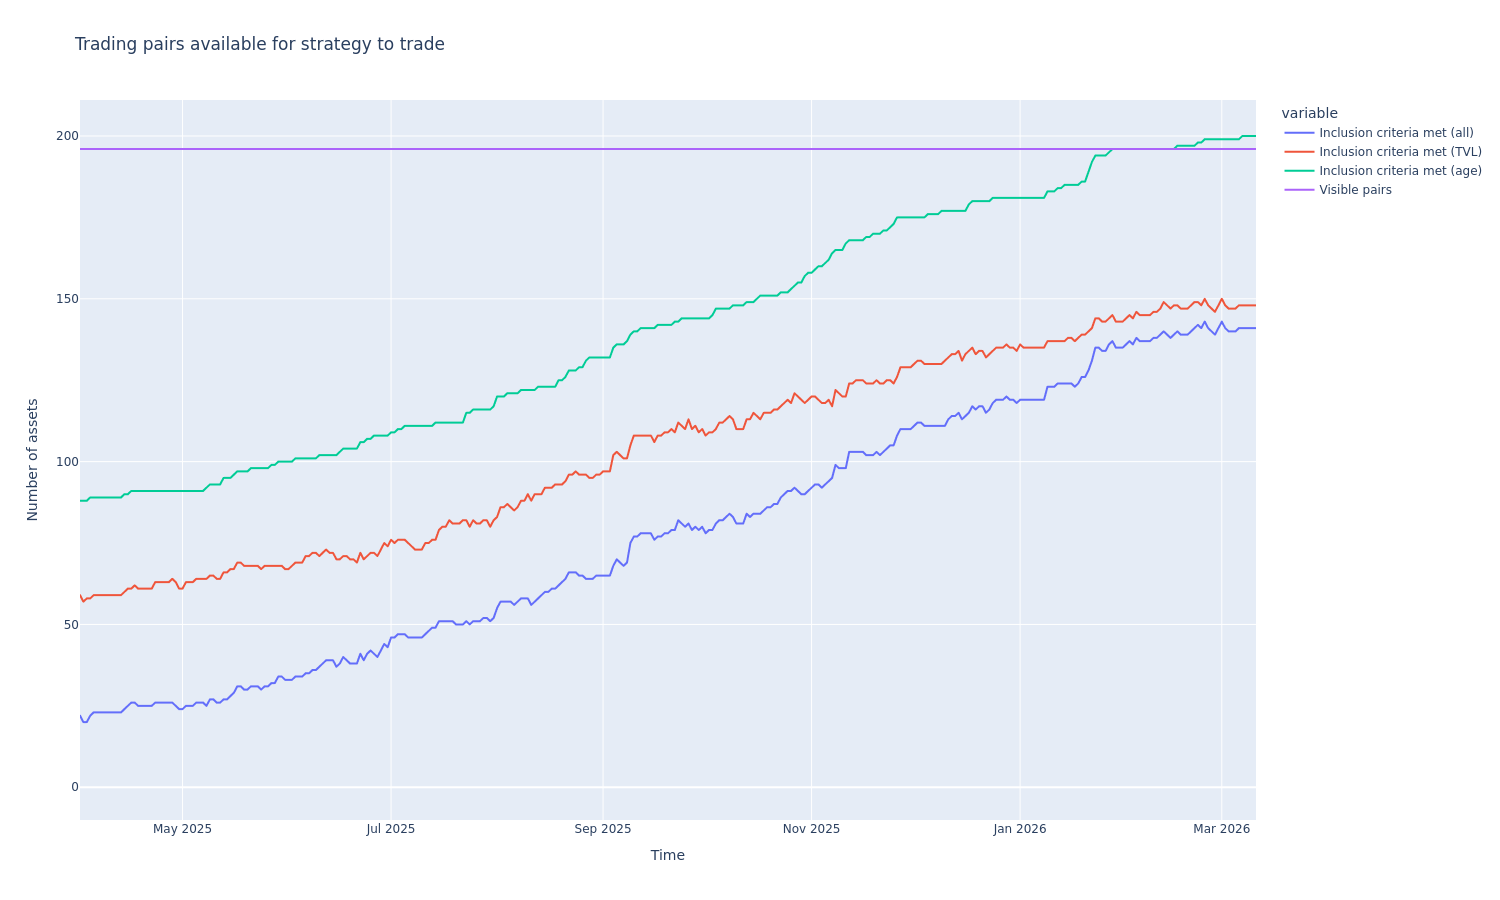

Head (5 rows)


,Inclusion criteria met (all),Inclusion criteria met (TVL),Inclusion criteria met (age),Visible pairs
2024-06-01,1,10,14,195
2024-06-02,3,13,17,195
2024-06-03,3,13,17,195
2024-06-04,3,15,19,195
2024-06-05,3,15,19,195


Tail (5 rows)


,Inclusion criteria met (all),Inclusion criteria met (TVL),Inclusion criteria met (age),Visible pairs
2026-03-07,141,148,200,196
2026-03-08,141,148,200,196
2026-03-09,141,148,200,196
2026-03-10,141,148,200,196
2026-03-11,141,148,200,196


In [11]:
fig, available_trading_pairs_df = chart_renderer.render(available_trading_pairs, with_dataframe=True)
fig.show()
display_head_and_tail(available_trading_pairs_df, head_rows=5, tail_rows=5)

## CCTP trade diagnostics

Inspect bridge direction, destination chain, size, and status when the run creates CCTP bridge trades.

In [12]:
from tradeexecutor.analysis.cctp import build_bridge_trade_dataframe, build_bridge_trade_summary

expected_destination_chain_ids = {
    chain_id.value
    for chain_id, _address in Parameters.source_vaults
    if chain_id != Parameters.primary_chain_id
}

if bridge_trades:
    bridge_df = build_bridge_trade_dataframe(bridge_trades)
    display_head_and_tail(bridge_df, head_rows=10, tail_rows=10)

    bridge_summary_df = build_bridge_trade_summary(bridge_df)
    display(bridge_summary_df)

    observed_destination_chain_ids = set(bridge_df["destination_chain_id"]) if not bridge_df.empty else set()

    assert observed_destination_chain_ids.issubset(expected_destination_chain_ids), (
        f"Unexpected bridge destinations {observed_destination_chain_ids}; expected subset of {expected_destination_chain_ids}"
    )
    assert "bridge out" in set(bridge_df["direction"]), "Expected bridge-out trades"
    assert bridge_df["value_usd"].sum() > 0
else:
    bridge_df = pd.DataFrame()
    bridge_summary_df = pd.DataFrame(
        [("CCTP bridge trades", 0), ("Expected destination chains", sorted(expected_destination_chain_ids))],
        columns=["Metric", "Value"],
    )
    display(bridge_summary_df)


Head (10 rows)


,trade_id,opened_at,executed_at,direction,source_chain_id,destination_chain_id,value_usd,quantity,status,position_id
6,10,2025-04-01,2025-04-01,bridge out,1,8453,32040.000000,32040.000000,success,10
9,11,2025-04-01,2025-04-01,bridge out,1,42161,5178.401117,5178.401117,success,11
7,14,2025-04-04,2025-04-04,bridge back,1,8453,1244.716715,-1244.716715,success,10
8,16,2025-04-05,2025-04-05,bridge back,1,8453,10.635560,-10.635560,success,12
10,19,2025-04-06,2025-04-06,bridge back,1,42161,121.182239,-121.182239,success,11
11,22,2025-04-07,2025-04-07,bridge back,1,8453,202.035446,-202.035446,success,13
12,25,2025-04-08,2025-04-08,bridge out,1,42161,72.145638,72.145638,success,14
14,29,2025-04-09,2025-04-09,bridge back,1,8453,11.944968,-11.944968,success,15
13,30,2025-04-09,2025-04-09,bridge back,1,42161,230.458653,-230.458653,success,14
15,33,2025-04-10,2025-04-10,bridge out,1,8453,1445.382976,1445.382976,success,16


Tail (10 rows)


,trade_id,opened_at,executed_at,direction,source_chain_id,destination_chain_id,value_usd,quantity,status,position_id
380,2045,2026-02-24,2026-02-24,bridge back,1,8453,621.300302,-621.300302,success,336
381,2061,2026-02-26,2026-02-26,bridge out,1,8453,5120.850860,5120.850860,success,336
382,2066,2026-02-27,2026-02-27,bridge back,1,8453,4179.893040,-4179.893040,success,336
383,2071,2026-02-28,2026-02-28,bridge back,1,8453,8761.644950,-8761.644950,success,336
384,2073,2026-03-01,2026-03-01,bridge out,1,8453,1263.133116,1263.133116,success,336
385,2077,2026-03-02,2026-03-02,bridge back,1,8453,1761.401549,-1761.401549,success,336
3,2079,2026-03-03,2026-03-03,bridge out,1,8453,2026.085497,2026.085497,success,345
4,2082,2026-03-04,2026-03-04,bridge back,1,8453,2026.403357,-2026.403357,success,345
5,2100,2026-03-10,2026-03-10,bridge out,1,8453,2428.552238,2428.552238,success,345
2,2101,2026-03-10,2026-03-10,bridge out,1,42161,1276.780837,1276.780837,success,330


,destination_chain_id,direction,trades,value_usd,first_trade,last_trade
0,8453,bridge back,123,459862.285049,2025-04-04,2026-03-04
1,8453,bridge out,95,467369.666188,2025-04-01,2026-03-10
2,42161,bridge back,90,232946.133002,2025-04-06,2026-02-18
3,42161,bridge out,78,258267.105739,2025-04-01,2026-03-10


## Bridge and vault sequencing

Summarise cycles containing bridge and satellite vault trades. This shows whether the run exercised the CCTP bridge-trade injection path.

In [13]:
rows = []
for trade in trades:
    rows.append({
        "cycle": trade.strategy_cycle_at,
        "trade_id": trade.trade_id,
        "kind": trade.pair.kind.value,
        "chain_id": trade.pair.chain_id,
        "is_bridge": trade.pair.is_cctp_bridge(),
        "is_satellite_vault": trade.pair.kind.is_vault() and trade.pair.chain_id != Parameters.primary_chain_id.value,
        "value_usd": trade.get_value(),
        "status": trade.get_status().value,
    })

trade_df = pd.DataFrame(rows)
if trade_df.empty:
    cycle_df = pd.DataFrame()
else:
    cycle_df = trade_df.groupby("cycle").agg(
        trades=("trade_id", "count"),
        bridge_trades=("is_bridge", "sum"),
        satellite_vault_trades=("is_satellite_vault", "sum"),
        traded_value_usd=("value_usd", "sum"),
    ).reset_index()
    cycle_df["satellite_vaults_without_same_cycle_bridge"] = (
        (cycle_df["satellite_vault_trades"] > 0)
        & (cycle_df["bridge_trades"] == 0)
    )

display_head_and_tail(cycle_df, head_rows=10, tail_rows=10)

Head (10 rows)


,cycle,trades,bridge_trades,satellite_vault_trades,traded_value_usd,satellite_vaults_without_same_cycle_bridge
0,2025-04-01,11,2,4,125923.691520,False
1,2025-04-04,3,1,1,3739.998276,False
2,2025-04-05,2,1,1,21.271121,False
3,2025-04-06,3,1,1,358.154893,False
4,2025-04-07,3,1,1,604.860652,False
5,2025-04-08,3,1,1,215.296867,False
6,2025-04-09,5,2,2,716.467776,False
7,2025-04-10,3,1,1,4337.557893,False
8,2025-04-11,4,1,1,32081.711758,False
9,2025-04-15,2,1,1,22.777553,False


Tail (10 rows)


,cycle,trades,bridge_trades,satellite_vault_trades,traded_value_usd,satellite_vaults_without_same_cycle_bridge
260,2026-03-01,2,1,1,3024.259672,False
261,2026-03-02,4,1,2,6476.672538,False
262,2026-03-03,2,1,1,4052.170994,False
263,2026-03-04,3,1,2,4125.536649,False
264,2026-03-05,2,0,0,2397.765662,False
265,2026-03-06,2,0,2,5622.885459,True
266,2026-03-07,2,0,0,7896.515735,False
267,2026-03-08,3,0,2,3507.948639,True
268,2026-03-09,2,0,0,13230.090698,False
269,2026-03-10,8,2,4,30566.167170,False


## Profit calculation check

Double-check the profit calculation directly from the equity curve and portfolio final equity.


In [14]:
curve_start = float(equity_curve.iloc[0])
curve_end = float(equity_curve.iloc[-1])
curve_return = curve_end / curve_start - 1
portfolio_return = final_equity / Parameters.initial_cash - 1

profit_check_df = pd.DataFrame(
    [
        ("Equity curve start", curve_start),
        ("Equity curve end", curve_end),
        ("Equity curve return", curve_return),
        ("Portfolio final equity", final_equity),
        ("Portfolio return", portfolio_return),
        ("Absolute difference", abs(curve_end - final_equity)),
    ],
    columns=["Metric", "Value"],
)

display(profit_check_df)

assert abs(curve_end - final_equity) < 0.01
assert curve_return > 0
assert abs(curve_return - portfolio_return) < 0.0001

,Metric,Value
0,Equity curve start,100000.000000
1,Equity curve end,106903.156785
2,Equity curve return,0.069032
3,Portfolio final equity,106903.156785
4,Portfolio return,0.069032
5,Absolute difference,0.000000


## Equity curve

Plot the resulting equity curve and daily return distribution.


### Equity curve chart

Visualise total portfolio equity through the backtest so drawdowns, recovery periods, and final profitability are visible at a glance.


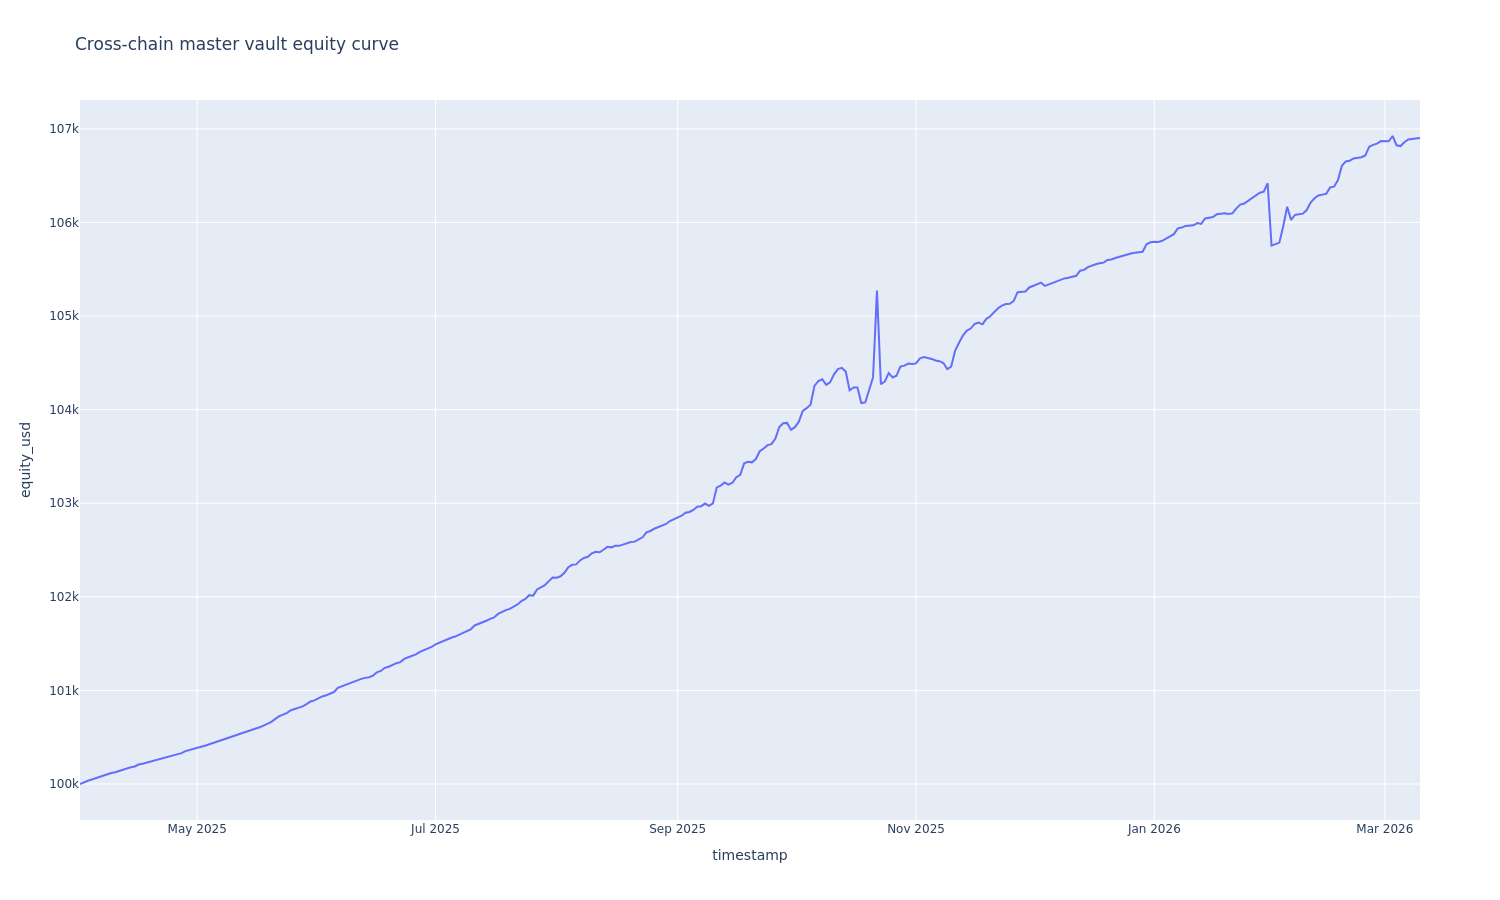

In [15]:
equity_df = equity_curve.rename("equity_usd").reset_index()
equity_df.columns = ["timestamp", "equity_usd"]
fig = px.line(equity_df, x="timestamp", y="equity_usd", title="Cross-chain master vault equity curve")
fig.show()

### Daily return distribution chart

Show the distribution of daily strategy returns to make outlier days and return skew easier to inspect.


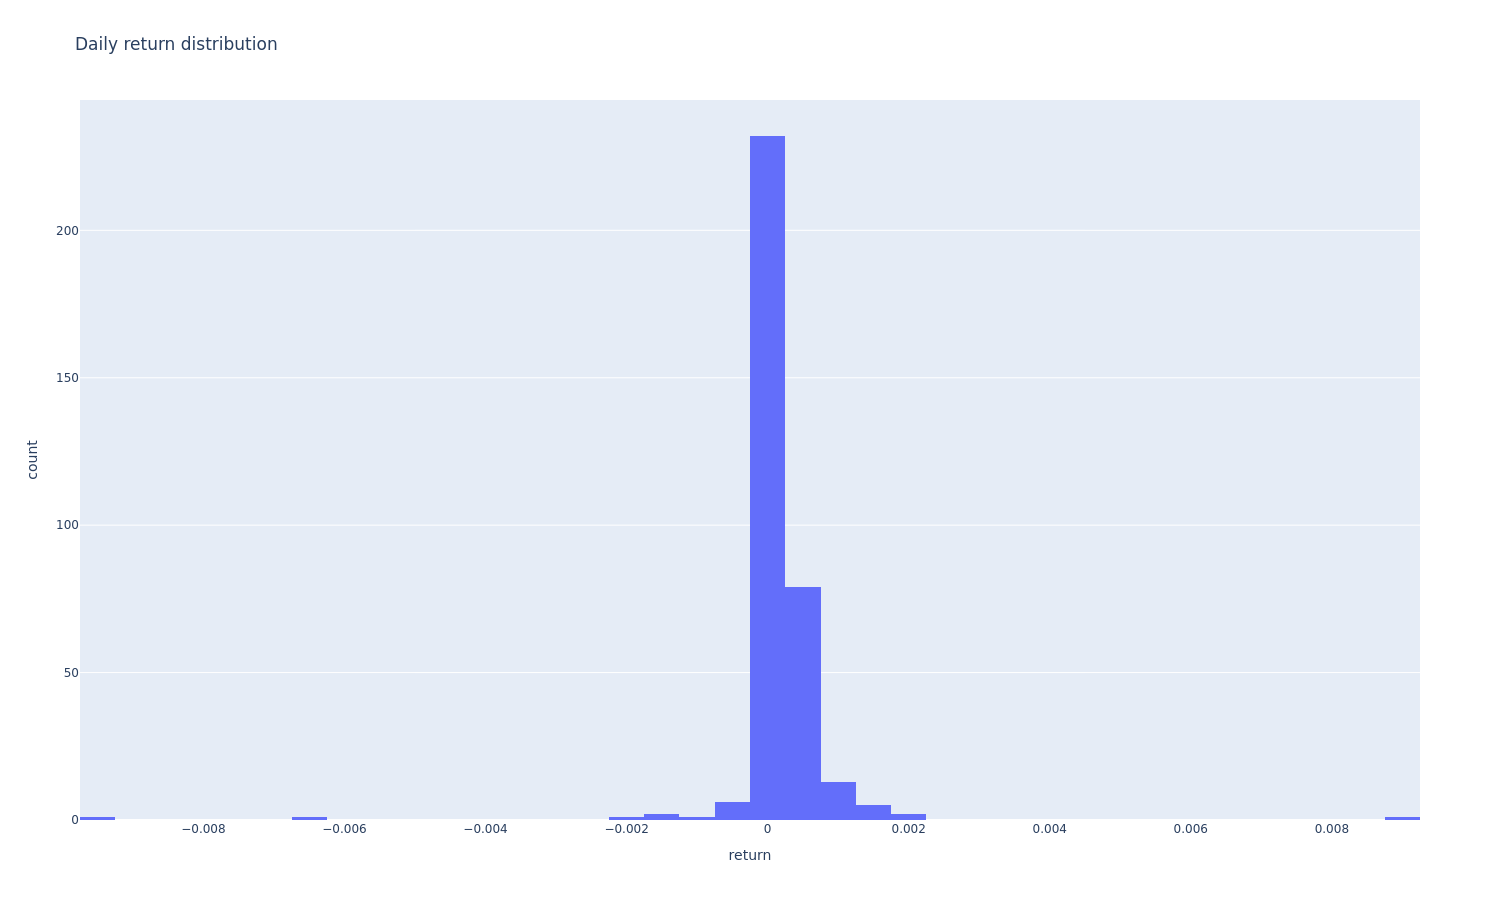

In [16]:
returns_df = returns.rename("return").reset_index()
returns_df.columns = ["timestamp", "return"]
fig = px.histogram(returns_df, x="return", nbins=50, title="Daily return distribution")
fig.show()

## Vault and chain diagnostics

Summarise final open exposure by chain and show the tail of the executed vault trades.


In [17]:
from tradeexecutor.analysis.position import build_chain_exposure_snapshot

positions_df, chain_exposure_df = build_chain_exposure_snapshot(
    state.portfolio.get_open_and_frozen_positions()
)
display(chain_exposure_df)
display_head_and_tail(positions_df, head_rows=10, tail_rows=5)

,chain_id,positions,value_usd,weight
0,1,8,45112.212469,0.559446
1,8453,2,10028.591275,0.124367
2,42161,3,25496.526973,0.316188


,position_id,chain_id,pair,value_usd,opened_at
1,163,42161,plvHedge-USDC,8931.551823,2025-10-19
8,315,42161,oLP-USDC,8656.625239,2026-02-09
10,346,1,B4B-USDC,8198.751140,2026-03-05
11,349,42161,HYPE++-USDC,7908.349912,2026-03-10
12,350,8453,HYPE++-USDC,7908.349912,2026-03-10
2,216,1,HubCap-USDC-USDC,7648.309302,2025-12-08
6,286,1,synUSDx-USDC,7585.103345,2026-01-24
3,259,1,synUSD-USDC,7585.103345,2026-01-08
5,285,1,MPL-aqUSDC1-USDC,4949.351970,2026-01-23
7,313,1,gamiusdc-USDC,4925.295856,2026-02-07


## Result analysis

Render the standard chart registry from the production strategy for performance and allocation review.


### Performance metrics table

Summarise headline backtest performance metrics from the standard chart registry.


In [18]:
performance_metrics_df = chart_renderer.render(performance_metrics)
display(performance_metrics_df)

,Strategy,BTC,ETH
Start Period,2025-04-01,2025-04-01,2025-04-01
End Period,2026-03-10,2026-03-10,2026-03-10
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,100.0%,100.0%,100.0%
Cumulative Return,6.9%,-18.31%,6.85%
CAGR﹪,7.36%,-19.36%,7.31%
Sharpe,4.3,-0.26,0.47
Prob. Sharpe Ratio,99.53%,39.96%,67.57%
Smart Sharpe,3.2,-0.2,0.35
Sortino,5.82,-0.37,0.72


### Latest cycle snapshot

Cash, allocation, and redemption breakdown for the most recent strategy cycle.

In [19]:
snapshot_df = chart_renderer.render(latest_cycle_snapshot)
display(snapshot_df)

,Metric,Value
0,Final cycle,2026-03-10 00:00:00
1,Total equity USD,106903.16
2,Cash USD,22146.9
3,Cash % of equity,0.207168
4,Redeemable capital USD,NaN
5,Pending redemptions USD,NaN
6,Investable equity USD,78082.54
7,Accepted investable equity USD,78082.54
8,Accepted / investable %,1.0
9,Allocated to signals USD,95212.84


### Asset weight chart

Visualise how portfolio allocation moved across vault assets during the backtest.


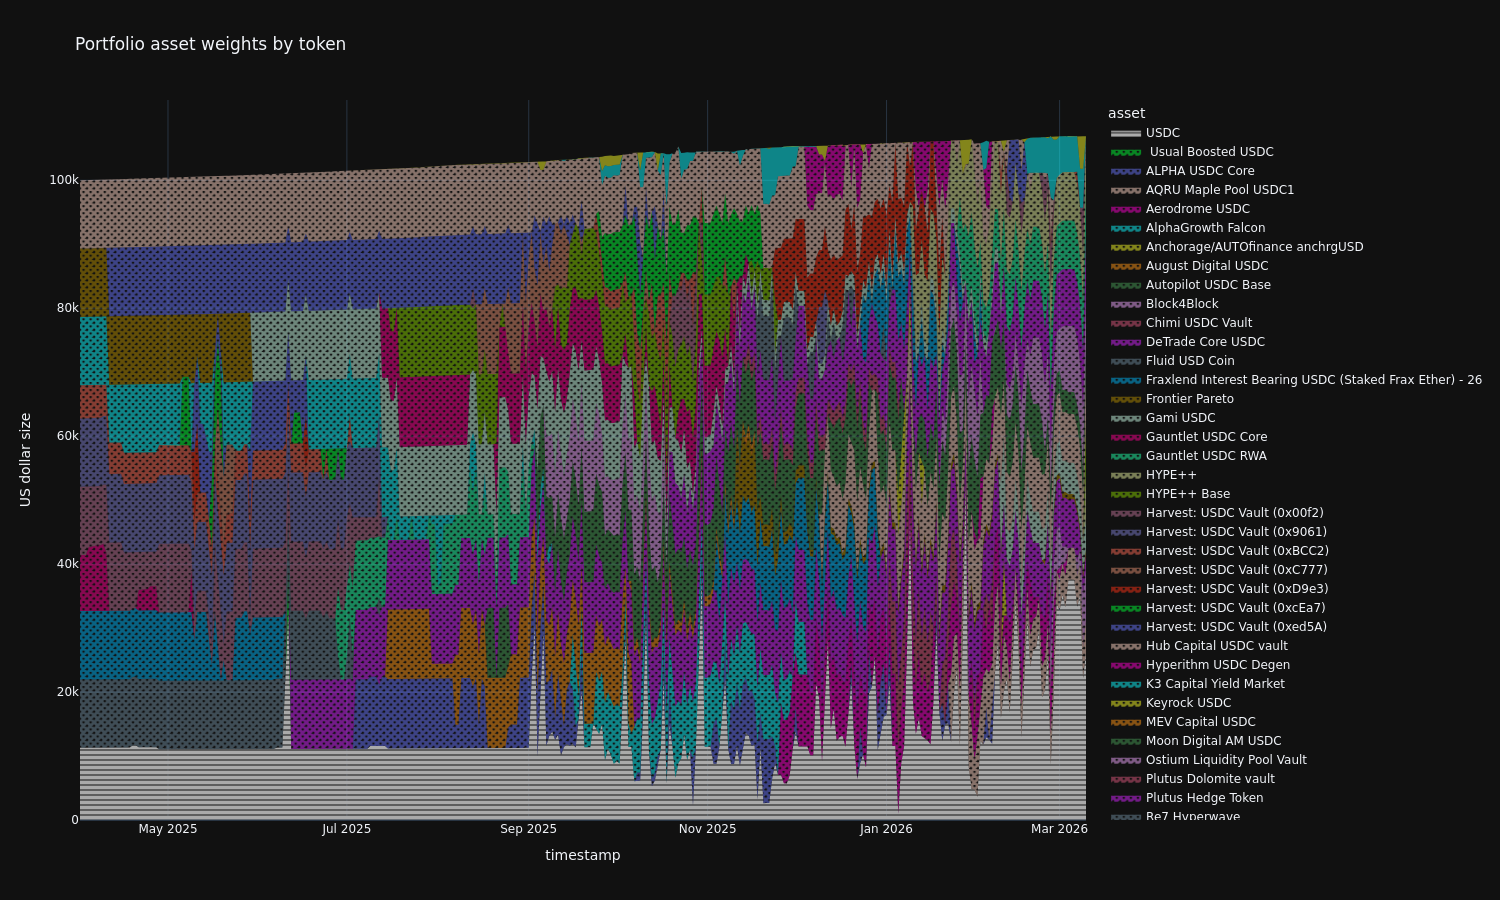

In [20]:
token_weights_fig = chart_renderer.render(equity_curve_by_asset)
token_weights_fig.update_layout(title="Portfolio asset weights by token")
token_weights_fig.show()

### Chain weight chart

Visualise cross-chain allocation between the primary chain and satellite chains, then show the underlying data sample.


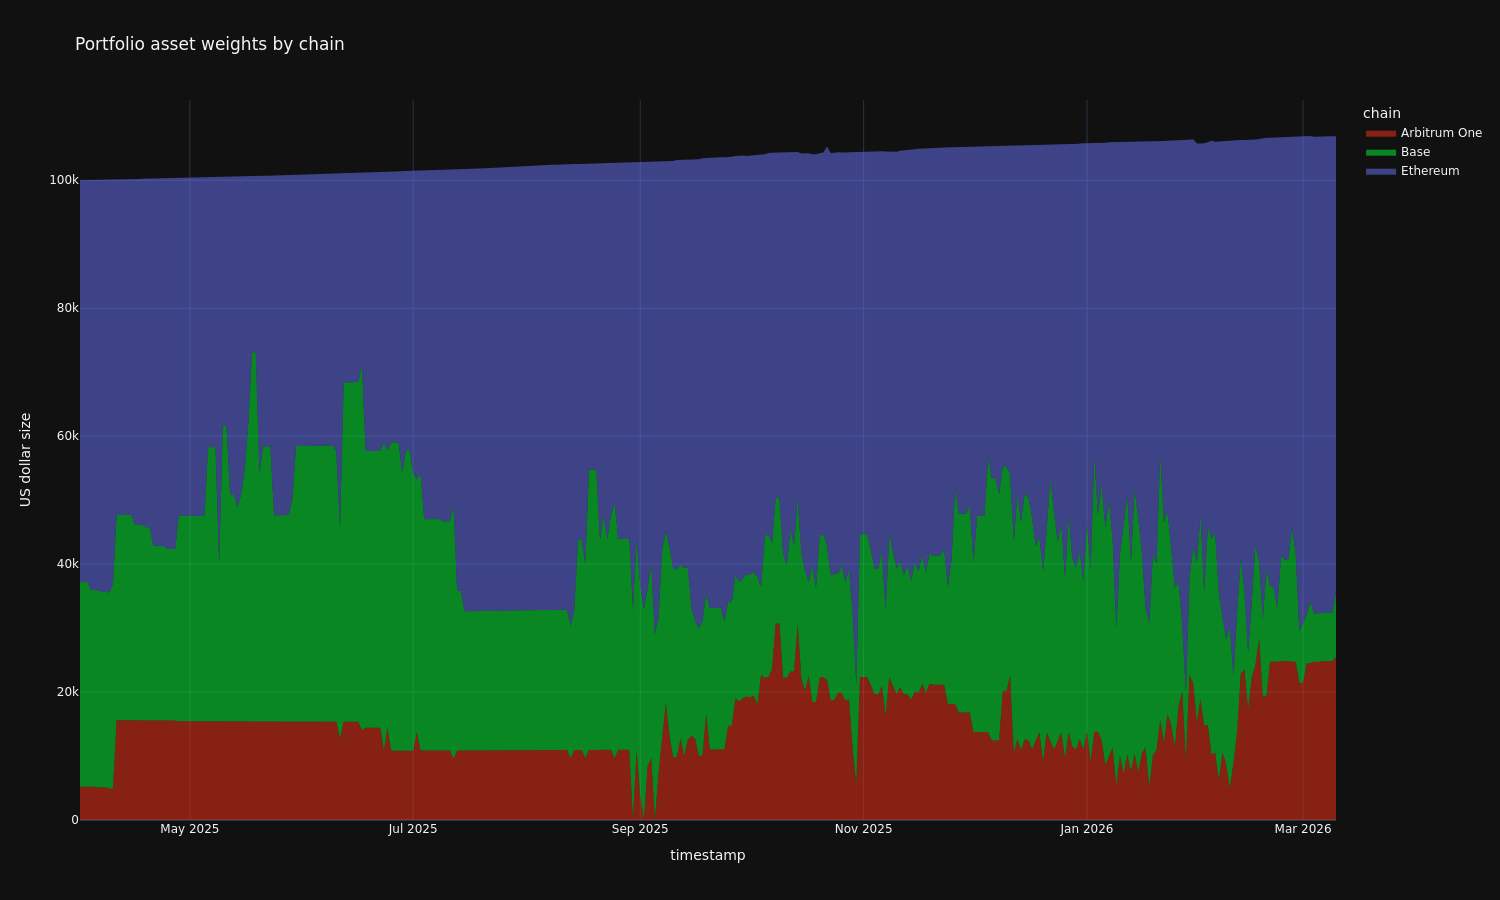

Head (10 rows)


chain,Arbitrum One,Base,Ethereum
timestamp,,,
2025-04-01,5178.401117,32040.000000,62781.598883
2025-04-02,5178.401117,32051.635184,62791.131959
2025-04-03,5180.592773,32058.615411,62795.845603
2025-04-04,5180.592773,30822.296229,64044.987375
2025-04-05,5180.592773,30818.342261,64064.402412
2025-04-06,5061.624508,30822.269747,64191.054819
2025-04-07,5061.624508,30629.338291,64399.962780
2025-04-08,5135.195634,30637.594756,64332.848710
2025-04-09,4905.161436,30632.706983,64580.189147


Tail (10 rows)


chain,Arbitrum One,Base,Ethereum
timestamp,,,
2026-03-01,21408.281442,9358.503354,76101.491144
2026-03-02,24483.994276,7597.376800,74786.254842
2026-03-03,24511.765639,9623.462296,72788.688071
2026-03-04,24730.259350,7599.631800,74494.824071
2026-03-05,24699.220118,7597.566980,74519.532264
2026-03-06,24810.062512,7597.566980,74449.677066
2026-03-07,24826.130386,7597.566980,74463.012079
2026-03-08,24822.084646,7598.035640,74470.860903
2026-03-09,24825.504464,7598.035640,74472.912666


In [21]:
chain_weights_fig, chain_weights_df = chart_renderer.render(equity_curve_by_chain)
chain_weights_fig.update_layout(title="Portfolio asset weights by chain")
chain_weights_fig.show()
display_head_and_tail(chain_weights_df, head_rows=10, tail_rows=10)

### Weight allocation statistics table

Summarise portfolio allocation behaviour across the backtest using the standard weight statistics table.


In [22]:
weight_allocation_statistics_df = chart_renderer.render(weight_allocation_statistics)
display(weight_allocation_statistics_df)

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2025-10-22,USDn2,"$12,130.33",
Min position (excluding USDC),2025-06-25,USDC (CCTP bridged to Arbitrum One),$0.00,
Mean position (excluding USDC),,,"$7,915.76",
Max position (excluding USDC),2026-01-09,DeTrade Core USDC,17.13%,
Min position (excluding USDC),2025-06-25,USDC (CCTP bridged to Arbitrum One),0.00%,
Mean position (excluding USDC),,,8.83%,
Max position (including USDC),2026-01-28,USDC,49.34%,
Min position (including USDC),2025-06-25,USDC (CCTP bridged to Arbitrum One),0.00%,
Mean position (including USDC),,,8.12%,


### Trading pair breakdown table

Show the final trading-pair diagnostics with chain metadata to inspect which vaults and bridges participated in the run.


In [23]:
trading_pair_breakdown_df = chart_renderer.render(trading_pair_breakdown_with_chain)
display_head_and_tail(trading_pair_breakdown_df, head_rows=10, tail_rows=10)

,Trading pair,Chain,Address,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
0,DeTrade Core USDC,Base,0x8092ca…,1,76,1.99%,864.83,1.99%,1.99%,1.99%,1.99%,"87,932.16",1,0,0,0,0,0.00%
35,Yield Chasing USDC,Arbitrum One,0x0df2e3…,13,56,1.93%,362.63,1.58%,0.00%,0.15%,0.02%,"236,372.51",9,4,0,0,0,0.41%
4,Moon Digital AM USDC,Ethereum,0xa00f63…,4,70,1.79%,427.23,0.94%,0.18%,0.45%,0.34%,"146,857.25",4,0,0,0,0,0.31%
30,Swaap Lend,Ethereum,0xf2f826…,10,66,1.51%,238.19,0.68%,0.00%,0.15%,0.06%,"225,185.15",6,4,0,0,0,0.21%
27,Harvest: USDC Vault (0x9061),Base,0x90613e…,1,14,1.50%,237.76,1.50%,1.50%,1.50%,1.50%,"31,984.94",1,0,0,0,0,0.00%
16,K3 Capital Yield Market,Ethereum,0xe0a80d…,12,45,1.48%,162.13,0.51%,0.02%,0.12%,0.07%,"194,589.00",12,0,0,0,0,0.15%
32,ALPHA USDC Core,Ethereum,0xb0f05e…,24,91,1.35%,227.42,0.40%,0.01%,0.06%,0.02%,"382,126.55",24,0,0,0,0,0.08%
2,Hub Capital USDC vault,Ethereum,0xca7903…,1,32,1.33%,341.62,1.33%,1.33%,1.33%,1.33%,"44,022.27",1,0,0,0,0,0.00%
10,Frontier Pareto,Ethereum,0xa94f9c…,3,21,1.27%,105.29,0.68%,0.18%,0.42%,0.41%,"32,144.31",3,0,0,0,0,0.20%
45,gTrade (Gains Network USDC),Base,0xad2052…,15,164,1.11%,860.20,0.67%,0.01%,0.07%,0.02%,"425,510.05",15,0,0,0,0,0.16%
